# ML Training

## Model Training

Now we are going to train the machine learning models. The main objectives of this stage are to:

1. **Establish a Random Forest as a baseline.**  
   No hyperparameter tuning will be performed for this model.

2. **Train and optimize an XGBoost model.** The optimization process will follow three steps:
   - **2.1. Randomized Search** for an initial exploration of the hyperparameter space.
   - **2.2. Grid Search** to refine the most promising hyperparameter combinations.
   - **2.3. Manual tuning** to make final adjustments based on the model's performance.

Before training the models, we will first perform the necessary **feature engineering** and **split the dataset** into training and test sets.

#### Libraries import

In [268]:
# ============================================================
# Step 0 - Import libraries
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Model selection
from sklearn.model_selection import (
    StratifiedGroupKFold,
    RandomizedSearchCV,
    GridSearchCV,
    cross_val_predict,
    cross_val_score
)

# Classification models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

# Feature importance and model interpretation
from sklearn.inspection import permutation_importance
import shap

# Model persistence
import joblib
import json


# Standard seed used throughout the notebook for reproducibility
SEED = 1

In [23]:
# IMPORTANT: If you are experiencing issues importing xgboost, you may need to install it first. You can do this by running the following command in a code cell:
# %pip install xgboost

In [262]:
# Same goes for shap, if you are experiencing issues importing it, you can install it by running:
# %pip install shap

In [ ]:
# This is a workaround to not restart the kernel after running all notebook cells. It invalidates the import caches, 
# so that the newly installed packages can be imported without restarting the kernel.
# import importlib
# importlib.invalidate_caches()

# import shap

#print(f"SHAP version: {shap.__version__}")

#### Data import

In [253]:
df = pd.read_csv('Wildfire_Dataset_model_ready.csv')
df

,Case_ID,Latitude,Longitude,Datetime,Wildfire,Precipitation_Today,Max_Relative_Humidity_Today,Min_Relative_Humidity_Today,Specific_Humidity_Today,Solar_Radiation_Today,...,Max_Relative_Humidity_Max_60_Days,Min_Relative_Humidity_Min_60_Days,Specific_Humidity_Average_60_Days,Solar_Radiation_Average_60_Days,Min_Daily_Temperature_Min_60_Days,Max_Daily_Temperature_Max_60_Days,Wind_Speed_Average_60_Days,Vapor_Pressure_Deficit_Average_60_Days,Actual_Evapotranspiration_Average_60_Days,Potential_Evapotranspiration_Average_60_Days
0,4,25.260270,-80.800990,2018-06-09,Yes,18.3,100.0,60.4,0.01751,269.8,...,100.0,30.9,0.015196,290.891667,11.75,33.45,4.753333,0.837500,6.538333,5.358333
1,5,25.260270,-80.800990,2014-06-10,No,14.9,100.0,59.6,0.01731,214.4,...,100.0,36.7,0.015300,299.580000,14.35,33.55,4.803333,0.907667,6.926667,5.640000
2,6,25.293970,-80.650540,2019-09-21,No,36.0,91.6,62.5,0.01751,185.4,...,100.0,54.3,0.019854,289.196667,23.35,34.95,3.956667,0.819833,6.478333,5.558333
3,9,25.293970,-80.650540,2022-09-20,Yes,4.2,100.0,58.1,0.01911,220.5,...,100.0,52.6,0.019282,285.795000,22.35,34.45,3.326667,0.961167,6.541667,5.605000
4,11,25.305556,-80.647500,2014-08-16,No,0.9,100.0,61.0,0.02177,281.4,...,100.0,47.4,0.019639,286.983333,20.35,35.65,2.968333,0.850333,6.255000,5.493333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59551,126789,48.996111,-96.500278,2023-12-07,Yes,0.0,88.8,47.1,0.00303,61.8,...,100.0,24.6,0.003329,75.568333,-19.95,19.85,3.721667,0.193167,1.158333,0.755000
59552,126792,48.996230,-116.093900,2017-08-29,Yes,0.0,43.3,19.5,0.00619,251.9,...,77.5,20.4,0.006515,293.313333,5.45,29.95,2.916667,1.300500,6.693333,5.225000
59553,126794,48.996230,-116.093900,2014-08-30,No,0.3,63.4,45.3,0.00570,238.7,...,83.2,21.2,0.007037,270.141667,5.55,28.55,2.946667,1.045333,5.830000,4.635000
59554,126798,48.998730,-114.042270,2017-09-07,Yes,0.0,61.6,20.8,0.00515,193.1,...,100.0,19.2,0.005521,258.125000,1.45,24.75,3.571667,0.938500,5.830000,4.430000


## Step 1: Feature Selection

In [25]:
drop_cols = ["Case_ID", "Latitude", "Longitude", "Datetime"]

X = df.drop(columns=drop_cols + ["Wildfire"])
y = df["Wildfire"].map({"Yes": 1, "No": 0})

We have nested variables, which means that 60 days has 30, 14 and 7 days included; 30 days has 14 and 7 days, and so on. Let's have a look into one of those to see what we can decide.

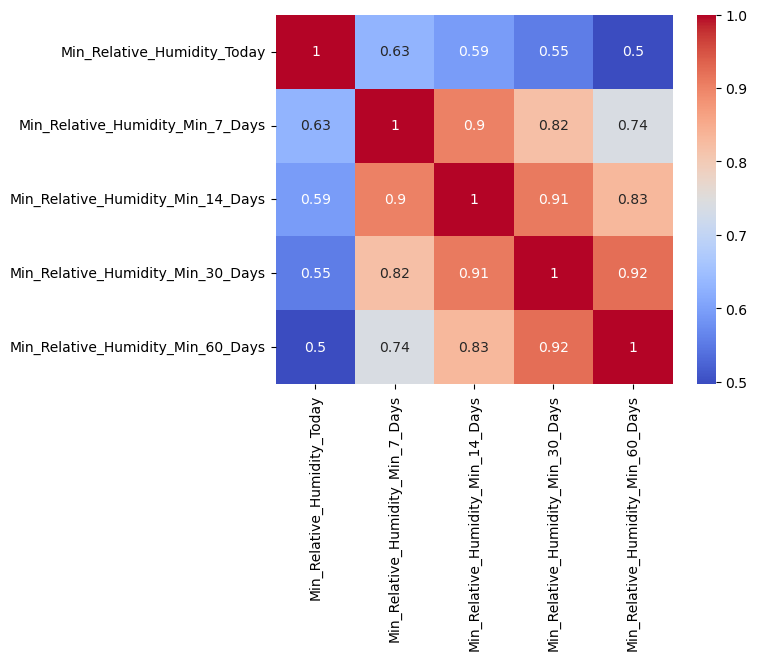

In [26]:
# Example of one variable.
cols_precip = [c for c in X.columns if c.__contains__("Humidity") and c.__contains__("Min")]
sns.heatmap(X[cols_precip].corr(), annot=True, cmap="coolwarm")
plt.show()

Let's have a look with all variables between them:

In [27]:
# =========================================================
# TEMPORAL REDUNDANCY ANALYSIS
# =========================================================

variables_to_check = [
    "Precipitation",
    "Max_Relative_Humidity",
    "Min_Relative_Humidity",
    "Specific_Humidity",
    "Solar_Radiation",
    "Min_Daily_Temperature",
    "Max_Daily_Temperature",
    "Wind_Speed",
    "Vapor_Pressure_Deficit",
    "Actual_Evapotranspiration",
    "Potential_Evapotranspiration"
]


for variable in variables_to_check:

    # Get all temporal features for the variable
    cols = [
        col for col in X.columns
        if col.startswith(variable + "_")
    ]

    # Correlation matrix
    corr = X[cols].corr()

    # Store unique feature pairs
    pairs = []

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            pairs.append({
                "Feature 1": cols[i],
                "Feature 2": cols[j],
                "Correlation": corr.iloc[i, j]
            })

    # Sort by absolute correlation (highest first)
    pairs = sorted(
        pairs,
        key=lambda x: abs(x["Correlation"]),
        reverse=True
    )

    # Print results
    print("\n" + "=" * 90)
    print(f"TEMPORAL REDUNDANCY - {variable}")
    print("=" * 90)

    for pair in pairs:

        print(
            f"{pair['Feature 1']}  <->  "
            f"{pair['Feature 2']}  :  "
            f"{pair['Correlation']:.2f}"
        )


TEMPORAL REDUNDANCY - Precipitation
Precipitation_Average_30_Days  <->  Precipitation_Average_60_Days  :  0.85
Precipitation_Average_14_Days  <->  Precipitation_Average_30_Days  :  0.80
Precipitation_Average_7_Days  <->  Precipitation_Average_14_Days  :  0.79
Precipitation_Average_14_Days  <->  Precipitation_Average_60_Days  :  0.66
Precipitation_Average_7_Days  <->  Precipitation_Average_30_Days  :  0.62
Precipitation_Average_7_Days  <->  Precipitation_Average_60_Days  :  0.50
Precipitation_Today  <->  Precipitation_Average_30_Days  :  0.19
Precipitation_Today  <->  Precipitation_Average_14_Days  :  0.19
Precipitation_Today  <->  Precipitation_Average_60_Days  :  0.19
Precipitation_Today  <->  Precipitation_Average_7_Days  :  0.18

TEMPORAL REDUNDANCY - Max_Relative_Humidity
Max_Relative_Humidity_Max_7_Days  <->  Max_Relative_Humidity_Max_14_Days  :  0.88
Max_Relative_Humidity_Max_14_Days  <->  Max_Relative_Humidity_Max_30_Days  :  0.87
Max_Relative_Humidity_Max_30_Days  <->  Max_Rel

60-day features were removed because they showed high correlation with the corresponding 30-day features, suggesting that they provide limited additional information while increasing model complexity.
Although longer-term weather conditions may provide useful background context, the 30-day window was considered sufficient to capture this medium-term environmental state.

In [28]:
# =========================================================
# REMOVE 60-DAY FEATURES
# =========================================================

X = X.drop(
    columns=[col for col in X.columns if "_60_Days" in col]
)

print(f"Number of features after removing 60-day windows: {X.shape[1]}")

Number of features after removing 60-day windows: 44


In [29]:
# =========================================================
# CORRELATION BETWEEN ALL REMAINING WEATHER FEATURES
# =========================================================

# Correlation matrix
corr_matrix = X.corr()

# Get unique feature pairs
pairs = []

for i in range(len(X.columns)):
    for j in range(i + 1, len(X.columns)):

        correlation = corr_matrix.iloc[i, j]

        pairs.append({
            "Feature 1": X.columns[i],
            "Feature 2": X.columns[j],
            "Correlation": correlation
        })

# Sort by absolute correlation
pairs = sorted(
    pairs,
    key=lambda x: abs(x["Correlation"]),
    reverse=True
)

# =========================================================
# PRINT ONLY STRONG CORRELATIONS
# =========================================================

threshold = 0.70

print("=" * 100)
print("STRONG CORRELATIONS BETWEEN WEATHER FEATURES")
print(f"Threshold: |r| >= {threshold}")
print("=" * 100)

for pair in pairs:

    if abs(pair["Correlation"]) >= threshold:

        print(
            f"{pair['Feature 1']}  <->  "
            f"{pair['Feature 2']}  :  "
            f"{pair['Correlation']:.2f}"
        )

STRONG CORRELATIONS BETWEEN WEATHER FEATURES
Threshold: |r| >= 0.7
Actual_Evapotranspiration_Average_30_Days  <->  Potential_Evapotranspiration_Average_30_Days  :  0.99
Actual_Evapotranspiration_Average_14_Days  <->  Potential_Evapotranspiration_Average_14_Days  :  0.99
Actual_Evapotranspiration_Average_7_Days  <->  Potential_Evapotranspiration_Average_7_Days  :  0.99
Actual_Evapotranspiration_Today  <->  Potential_Evapotranspiration_Today  :  0.99
Solar_Radiation_Average_7_Days  <->  Solar_Radiation_Average_14_Days  :  0.99
Solar_Radiation_Average_14_Days  <->  Solar_Radiation_Average_30_Days  :  0.98
Potential_Evapotranspiration_Average_7_Days  <->  Potential_Evapotranspiration_Average_14_Days  :  0.98
Potential_Evapotranspiration_Average_14_Days  <->  Potential_Evapotranspiration_Average_30_Days  :  0.98
Actual_Evapotranspiration_Average_14_Days  <->  Actual_Evapotranspiration_Average_30_Days  :  0.97
Actual_Evapotranspiration_Average_7_Days  <->  Actual_Evapotranspiration_Average_1

In [30]:
# Remove Actual Evapotranspiration
X = X.drop(
    columns=[col for col in X.columns if col.startswith("Actual_Evapotranspiration")]
)

print(f"Number of features after selection: {X.shape[1]}")

Number of features after selection: 40


### Feature Selection - Summary

The 60-day features were removed because they showed high correlation with the corresponding 30-day features across most meteorological variables, suggesting that they provide limited additional information while increasing model complexity. Although longer-term conditions may provide useful environmental context, the 30-day window was considered sufficient to capture the medium-term conditions preceding the event.

In addition, Actual Evapotranspiration was removed because it showed an almost perfect correlation with Potential Evapotranspiration across all remaining time windows (r ≈ 0.99). Therefore, retaining both variables would introduce substantial redundancy without providing significant additional information.

We therefore retained the following meteorological variables:

- Precipitation
- Max Relative Humidity
- Min Relative Humidity
- Specific Humidity
- Solar Radiation
- Min Daily Temperature
- Max Daily Temperature
- Wind Speed
- Vapor Pressure Deficit
- Potential Evapotranspiration

For each variable, the remaining temporal windows are Today, 7 days, 14 days, and 30 days.

This results in 40 meteorological features for the subsequent modelling stage.

## Step 2: Train / Test Split

First we are going to see the Wildfire distribution:

In [31]:
# Calculate the overall wildfire vs. non-wildfire distribution.
# Each Case_ID represents one observation.

wildfire_counts = df["Wildfire"].value_counts().sort_index()
wildfire_percentages = df["Wildfire"].value_counts(normalize=True).sort_index() * 100

print("Overall wildfire distribution:")
print(f"No wildfire: {wildfire_counts.get(0, 0):,} ({wildfire_percentages.get(0, 0):.2f}%)")
print(f"Wildfire:    {wildfire_counts.get(1, 0):,} ({wildfire_percentages.get(1, 0):.2f}%)")

Overall wildfire distribution:
No wildfire: 27,458 (46.10%)
Wildfire:    32,098 (53.90%)


/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_2098/607034117.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"No wildfire: {wildfire_counts.get(0, 0):,} ({wildfire_percentages.get(0, 0):.2f}%)")
/var/folders/b4/svxttqvs5zg_rg_drrxn_vf00000gn/T/ipykernel_2098/607034117.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Wildfire:    {wildfire_counts.get(1, 0):,} ({wildfire_percentages.get(1, 0):.2f}%)")


### Train/Test Split

To evaluate how well the model generalizes to previously unseen geographical locations, the dataset is split at the location level rather than randomly at the row level.

A random train/test split could place different cases from the same geographical location in both the training and test sets. Since each location can contain multiple temporal windows, this could allow the model to be evaluated on locations that it has already encountered during training, potentially leading to overly optimistic performance estimates.

To prevent this spatial leakage, `Latitude` and `Longitude` are used to define a unique geographical group for each location. These variables are used only to define the groups and are not used as model features. All cases belonging to the same geographical location are therefore kept entirely within either the training or test set.

A `StratifiedGroupKFold` with 5 folds is used to create the split. The first fold is selected, resulting in approximately 80% of the data being assigned to the training set and 20% to the test set. Stratification ensures that the proportion of wildfire and non-wildfire cases remains consistent across both sets, while grouping prevents geographical locations from being shared between them.

The resulting split contains 47,645 training samples and 11,911 test samples. The wildfire proportion is 53.89% in the training set and 53.92% in the test set, confirming that the target distribution is well preserved.

Finally, the geographical overlap between the two sets is explicitly checked and confirmed to be zero. This provides a more realistic evaluation of the model's ability to generalize to geographical locations that were not observed during training.

In [32]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

# Create a group identifier for each geographical location.
# Each combination of Latitude + Longitude represents one location.
# This prevents the same location from appearing in both
# the training and test sets.
groups = (
    df["Latitude"].astype(str)
    + "_"
    + df["Longitude"].astype(str)
)

# StratifiedGroupKFold allows us to split the data while considering
# two aspects:
# 1. Keep a similar proportion of 0s and 1s in train and test.
# 2. Keep geographical locations separated between train and test.
splitter = StratifiedGroupKFold(
    n_splits=5,       # Split the data into 5 groups (folds).
    shuffle=True,     # Shuffle the groups before splitting.
    random_state=SEED   # Ensures the split is reproducible.
)

# Generate the train and test indices.
# next() selects the first of the 5 possible splits.
train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

# Use the indices to create the training and test feature sets.
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

# Apply the same indices to the target variable.
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

# Check the size of the training and test sets.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# Check the proportion of each target class in the training set.
# The proportions should remain reasonably similar to the original data.
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))

# Check the proportion of each target class in the test set.
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (47645, 40)
X_test: (11911, 40)

y_train distribution:
Wildfire
1    0.538902
0    0.461098
Name: proportion, dtype: float64

y_test distribution:
Wildfire
1    0.539165
0    0.460835
Name: proportion, dtype: float64


In [33]:
# =========================================================
# CHECK FOR SPATIAL OVERLAP
# =========================================================

# Create sets containing the unique geographical locations
# present in the training and test sets.
train_locations = set(
    zip(
        df.iloc[train_idx]["Latitude"],
        df.iloc[train_idx]["Longitude"]
    )
)

test_locations = set(
    zip(
        df.iloc[test_idx]["Latitude"],
        df.iloc[test_idx]["Longitude"]
    )
)

# Find locations that appear in both datasets.
overlapping_locations = train_locations.intersection(test_locations)

# Print the number of overlapping locations.
print("Overlapping locations:", len(overlapping_locations))

Overlapping locations: 0


## Step 3: Feature Engeneering

Tree-based models (Decision Tree, Random Forest, XGBoost) don't need feature scaling, and this dataset has no missing values or categorical variables. There is no Feature Engineering to do here beyond the feature selection already done in Step 1.

# Random Forest

## Step 4: Random Forest

In [34]:
# =========================================================
# STEP 4 - MODEL TRAINING: RANDOM FOREST CLASSIFIER
# =========================================================

rf_clf = RandomForestClassifier(
    n_estimators=300,          # Number of trees in the forest. More trees = more stable
                                # average prediction and lower variance, at the cost of
                                # compute time. 300-500 is a common standard range; gains
                                # beyond that are usually marginal.

    max_depth=10,               # Maximum depth of each tree. This is the main lever against
                                # overfitting: an unlimited depth lets trees grow until they
                                # memorize the training data. 8-15 is a typical standard
                                # starting range for tabular data with a few dozen features.

    min_samples_split=10,       # Minimum number of samples required to split an internal
                                # node. Higher values prevent the tree from creating splits
                                # based on very few (possibly noisy) observations.

    min_samples_leaf=4,         # Minimum number of samples required to be at a leaf node.
                                # Similar purpose to min_samples_split, but applied at the
                                # final node. Standard practice is to keep this a bit lower
                                # than min_samples_split (roughly half).

    max_features="sqrt",        # Number of features considered when looking for the best
                                # split at each node. "sqrt" (square root of total features)
                                # is the standard default for classification in scikit-learn
                                # and most ML literature -- it increases diversity between
                                # trees, which reduces correlation and improves generalization.

    bootstrap=True,             # Whether each tree is trained on a bootstrap sample (random
                                # sample with replacement) of the training data, rather than
                                # the full dataset. This is the "Random" in Random Forest --
                                # it's what makes each tree slightly different from the others.

    class_weight="balanced",    # Automatically adjusts weights inversely proportional to
                                # class frequency. Safe to include even if classes are close
                                # to balanced (as in your case) -- it won't hurt, and protects
                                # you if the balance shifts later (e.g. after further cleaning).

    random_state=SEED,          # Fixes the randomness (bootstrap sampling, feature selection)
                                # so results are reproducible across runs.

    n_jobs=-1                   # Uses all available CPU cores to train trees in parallel.
                                # Purely a performance setting, does not affect the model.
)
rf_clf.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


## Step 5: Results

In [35]:
# Step 5 - Results

# ----------------

# Evaluate the model on both Train and Test, to check for overfitting

y_pred_train = rf_clf.predict(X_train)
y_pred_test = rf_clf.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)

print(f'Accuracy (Train): {accuracy_train * 100:.2f}%')
print()

# Classification Report (Test)

# ----------------------------

print(classification_report(
    y_test,
    y_pred_test,
    target_names=['No wildfire', 'Wildfire']
))

Accuracy (Train): 72.82%

              precision    recall  f1-score   support

 No wildfire       0.67      0.55      0.61      5489
    Wildfire       0.67      0.77      0.71      6422

    accuracy                           0.67     11911
   macro avg       0.67      0.66      0.66     11911
weighted avg       0.67      0.67      0.66     11911



### Random Forest Performance

The Random Forest achieves a training accuracy of 72.82% and a test accuracy of 67.00%, resulting in a difference of 5.82 percentage points between the two sets. The relatively moderate training accuracy, combined with the limited gap between training and test performance, suggests that the model may be experiencing some degree of underfitting. This indicates that the current model may not be capturing all the underlying patterns in the data, leaving room for a more powerful model to improve performance.

For the wildfire class, the model achieves a precision of 0.67, a recall of 0.77, and an F1-score of 0.71. The relatively high recall indicates that the model correctly identifies a large proportion of wildfire cases in the test set. This is particularly relevant for a wildfire risk prediction problem, where failing to identify a potential wildfire may be more costly than generating a false alarm.

However, the precision of 0.67 indicates that not all cases predicted as wildfire are actual wildfire cases. This means that a considerable number of positive predictions are false positives, highlighting a trade-off between detecting a larger proportion of wildfire events and generating unnecessary alerts.

For the no-wildfire class, the model achieves a precision of 0.67, a recall of 0.55, and an F1-score of 0.61. The lower recall indicates that the model has more difficulty correctly identifying non-wildfire cases, tending to classify some of them as potential wildfire events.

Overall, the Random Forest provides a reasonable baseline for the wildfire prediction task. Its strongest characteristic is its relatively high wildfire recall (0.77), although this comes at the cost of a lower recall for the no-wildfire class (0.55). The test accuracy of 67.00% also indicates substantial room for improvement. The possible underfitting observed in the baseline suggests that a more powerful model may be able to capture additional patterns in the data. These results therefore provide a useful baseline against which the subsequent XGBoost models can be compared.

## Step 6 - Model Analysis

After training the Random Forest baseline, the next step is to analyse which features contribute most to the model's predictions.

This analysis has two main objectives:

1. Identify which environmental variables provide the most useful predictive information.
2. Determine whether the different temporal windows (7, 14, and 30 days) contribute equally or whether some windows are more informative than others.

The feature analysis will be based on permutation importance calculated on the test set. This method measures how much the model's performance decreases when the values of a feature are randomly shuffled while keeping the other features unchanged.

Permutation importance is preferred here over the Random Forest's built-in impurity-based feature importance because the dataset contains several correlated features, particularly different temporal representations of the same environmental variable.

The results will be used to guide feature reduction before training the next model. Feature reduction will only be considered successful if the reduced model maintains or improves predictive performance compared with the original Random Forest baseline.

#### Step 6.1 — Calculate permutation importance

In [46]:
# =========================================================
# STEP 6.1 - PERMUTATION IMPORTANCE
# =========================================================

# Calculate permutation importance on the test set.
# The values of each feature are randomly shuffled while
# keeping all other features unchanged.
#
# If model performance decreases after shuffling a feature,
# that feature contains useful predictive information.
perm_importance = permutation_importance(
    rf_clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

# Store the mean importance and its standard deviation
# in a DataFrame for easier analysis.
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

# Rank features from the most to the least important.
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Display the complete feature importance ranking.
feature_importance

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,Feature,Importance,Std
0,Precipitation_Average_30_Days,0.013727,0.001662
1,Precipitation_Average_14_Days,0.007749,0.001492
2,Specific_Humidity_Average_30_Days,0.004324,0.000982
3,Precipitation_Average_7_Days,0.003753,0.001800
4,Min_Relative_Humidity_Min_30_Days,0.003719,0.000688
5,Specific_Humidity_Average_14_Days,0.003543,0.001009
6,Potential_Evapotranspiration_Average_30_Days,0.003014,0.000949
7,Solar_Radiation_Average_7_Days,0.002838,0.001158
8,Solar_Radiation_Average_30_Days,0.002787,0.001259
9,Min_Relative_Humidity_Min_14_Days,0.002384,0.000599


#### Interpretation

The permutation importance results show that precipitation is the most influential variable, with the 30-day average being the strongest feature. Specific humidity, minimum relative humidity, potential evapotranspiration, and solar radiation also provide relevant predictive information.

The results suggest that longer-term conditions are particularly useful, although the most informative temporal window varies depending on the environmental variable. Several current-day features also contribute to the model.

Features with values close to zero or slightly negative provide little measurable contribution within the model and permutation variability.

Overall, the results support selecting the best temporal window separately for each environmental variable rather than removing entire groups of correlated features.

### Step 6.2 - Select the Best Temporal Window


The dataset contains 7, 14 and 30-day representations of the same environmental variables.

Instead of removing variables based only on their overall importance, we compare the different temporal windows within each environmental variable. This allows us to identify which time horizon provides the most useful predictive information for each variable.

The feature with the highest permutation importance within each group will be selected for the reduced feature set.

This approach reduces redundancy while preserving different types of environmental information.

In [47]:
# =========================================================
# STEP 6.2 - SELECT THE BEST TEMPORAL WINDOW
# =========================================================

# Group features that represent the same environmental
# variable across the 7-, 14-, and 30-day windows.
feature_groups = {
    "Precipitation": [
        "Precipitation_Average_7_Days",
        "Precipitation_Average_14_Days",
        "Precipitation_Average_30_Days"
    ],
    "Specific_Humidity": [
        "Specific_Humidity_Average_7_Days",
        "Specific_Humidity_Average_14_Days",
        "Specific_Humidity_Average_30_Days"
    ],
    "Min_Relative_Humidity": [
        "Min_Relative_Humidity_Min_7_Days",
        "Min_Relative_Humidity_Min_14_Days",
        "Min_Relative_Humidity_Min_30_Days"
    ],
    "Max_Relative_Humidity": [
        "Max_Relative_Humidity_Max_7_Days",
        "Max_Relative_Humidity_Max_14_Days",
        "Max_Relative_Humidity_Max_30_Days"
    ],
    "Solar_Radiation": [
        "Solar_Radiation_Average_7_Days",
        "Solar_Radiation_Average_14_Days",
        "Solar_Radiation_Average_30_Days"
    ],
    "Min_Temperature": [
        "Min_Daily_Temperature_Min_7_Days",
        "Min_Daily_Temperature_Min_14_Days",
        "Min_Daily_Temperature_Min_30_Days"
    ],
    "Max_Temperature": [
        "Max_Daily_Temperature_Max_7_Days",
        "Max_Daily_Temperature_Max_14_Days",
        "Max_Daily_Temperature_Max_30_Days"
    ],
    "Wind_Speed": [
        "Wind_Speed_Average_7_Days",
        "Wind_Speed_Average_14_Days",
        "Wind_Speed_Average_30_Days"
    ],
    "VPD": [
        "Vapor_Pressure_Deficit_Average_7_Days",
        "Vapor_Pressure_Deficit_Average_14_Days",
        "Vapor_Pressure_Deficit_Average_30_Days"
    ],
    "Potential_Evapotranspiration": [
        "Potential_Evapotranspiration_Average_7_Days",
        "Potential_Evapotranspiration_Average_14_Days",
        "Potential_Evapotranspiration_Average_30_Days"
    ]
}

# Create a lookup table for the permutation importance
# calculated in the previous step.
importance_lookup = feature_importance.set_index(
    "Feature"
)["Importance"]

# Select the most important temporal window for each
# environmental variable.
selected_temporal_features = []

for variable, features in feature_groups.items():

    best_feature = max(
        features,
        key=lambda feature: importance_lookup[feature]
    )

    selected_temporal_features.append(best_feature)

    print(
        f"{variable}: {best_feature} "
        f"(importance = {importance_lookup[best_feature]:.6f})"
    )

print("\nSelected temporal features:")

for feature in selected_temporal_features:
    print("-", feature)

Precipitation: Precipitation_Average_30_Days (importance = 0.013727)
Specific_Humidity: Specific_Humidity_Average_30_Days (importance = 0.004324)
Min_Relative_Humidity: Min_Relative_Humidity_Min_30_Days (importance = 0.003719)
Max_Relative_Humidity: Max_Relative_Humidity_Max_7_Days (importance = 0.001612)
Solar_Radiation: Solar_Radiation_Average_7_Days (importance = 0.002838)
Min_Temperature: Min_Daily_Temperature_Min_14_Days (importance = 0.001688)
Max_Temperature: Max_Daily_Temperature_Max_30_Days (importance = 0.000831)
Wind_Speed: Wind_Speed_Average_30_Days (importance = 0.001352)
VPD: Vapor_Pressure_Deficit_Average_30_Days (importance = 0.000495)
Potential_Evapotranspiration: Potential_Evapotranspiration_Average_30_Days (importance = 0.003014)

Selected temporal features:
- Precipitation_Average_30_Days
- Specific_Humidity_Average_30_Days
- Min_Relative_Humidity_Min_30_Days
- Max_Relative_Humidity_Max_7_Days
- Solar_Radiation_Average_7_Days
- Min_Daily_Temperature_Min_14_Days
- Ma

### Interpretation

The 30-day window is the most informative temporal representation for most environmental variables, including precipitation, specific humidity, minimum relative humidity, maximum temperature, wind speed, VPD, and potential evapotranspiration.

However, shorter windows are more informative for some variables. Maximum relative humidity and solar radiation perform best over 7 days, while minimum temperature performs best over 14 days.

Overall, the results indicate that the optimal temporal window depends on the environmental variable, although longer-term conditions are generally more informative for this model.

### Step 6.3 - Compare Selected Windows with Today Features


The selected temporal features represent the most informative historical window for each environmental variable.

The next step is to compare these features with the corresponding current-day (`Today`) features. This allows us to determine whether current conditions provide additional predictive information beyond the historical patterns.

The comparison will be based on permutation importance. Today features with meaningful importance will be considered for the reduced feature set.

In [48]:
# =========================================================
# STEP 6.3 - COMPARE SELECTED WINDOWS AND TODAY FEATURES
# =========================================================

# Define the features representing current-day conditions.
today_features = [
    "Precipitation_Today",
    "Max_Relative_Humidity_Today",
    "Min_Relative_Humidity_Today",
    "Specific_Humidity_Today",
    "Solar_Radiation_Today",
    "Min_Daily_Temperature_Today",
    "Max_Daily_Temperature_Today",
    "Wind_Speed_Today",
    "Vapor_Pressure_Deficit_Today",
    "Potential_Evapotranspiration_Today"
]

# Combine the selected temporal features with today's features.
features_to_compare = selected_temporal_features + today_features

# Retrieve their permutation importance from the previous analysis.
comparison = feature_importance[
    feature_importance["Feature"].isin(features_to_compare)
].copy()

# Sort the features from most to least important.
comparison = comparison.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Display the comparison.
comparison

,Feature,Importance,Std
0,Precipitation_Average_30_Days,0.013727,0.001662
1,Specific_Humidity_Average_30_Days,0.004324,0.000982
2,Min_Relative_Humidity_Min_30_Days,0.003719,0.000688
3,Potential_Evapotranspiration_Average_30_Days,0.003014,0.000949
4,Solar_Radiation_Average_7_Days,0.002838,0.001158
5,Min_Daily_Temperature_Min_14_Days,0.001688,0.000464
6,Solar_Radiation_Today,0.001679,0.000981
7,Max_Relative_Humidity_Max_7_Days,0.001612,0.001166
8,Wind_Speed_Average_30_Days,0.001352,0.000665
9,Min_Relative_Humidity_Today,0.001175,0.000815


### Interpretation

The comparison shows that several current-day features provide additional predictive information beyond the selected historical windows.

Solar radiation, minimum relative humidity, VPD, and wind speed show the strongest contribution among the `Today` features. Precipitation and specific humidity provide only a small additional contribution, while maximum humidity and temperature show very limited importance.

Therefore, the reduced feature set will retain the four most informative current-day features: solar radiation, minimum relative humidity, VPD, and wind speed.

### Step 6.4 - Create the Reduced Feature Set


Based on the previous analysis, the reduced feature set combines:

- One selected temporal window for each of the 10 environmental variables.
- The four most informative current-day features.

This results in a total of 14 features, compared with the original 40 features.

The reduced training and test datasets will be created using exactly these selected features.

In [49]:
# =========================================================
# STEP 6.4 - CREATE REDUCED FEATURE SET
# =========================================================

# Combine the best temporal feature for each variable
# with the four most informative current-day features.
selected_features = selected_temporal_features + [
    "Solar_Radiation_Today",
    "Min_Relative_Humidity_Today",
    "Vapor_Pressure_Deficit_Today",
    "Wind_Speed_Today"
]

# Remove any accidental duplicates while preserving the order.
selected_features = list(dict.fromkeys(selected_features))

# Create the reduced training and test datasets.
X_train_reduced = X_train[selected_features].copy()
X_test_reduced = X_test[selected_features].copy()

# Display the dimensionality reduction.
print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")

print("\nSelected features:")
for feature in selected_features:
    print("-", feature)

Original number of features: 40
Reduced number of features: 14

Selected features:
- Precipitation_Average_30_Days
- Specific_Humidity_Average_30_Days
- Min_Relative_Humidity_Min_30_Days
- Max_Relative_Humidity_Max_7_Days
- Solar_Radiation_Average_7_Days
- Min_Daily_Temperature_Min_14_Days
- Max_Daily_Temperature_Max_30_Days
- Wind_Speed_Average_30_Days
- Vapor_Pressure_Deficit_Average_30_Days
- Potential_Evapotranspiration_Average_30_Days
- Solar_Radiation_Today
- Min_Relative_Humidity_Today
- Vapor_Pressure_Deficit_Today
- Wind_Speed_Today


### Step 6.5 - Train Random Forest with the Reduced Feature Set

The reduced feature set contains 14 features selected through permutation importance and temporal-window analysis.

A new Random Forest model will be trained using only these features while keeping the same hyperparameters as the baseline model.

This allows us to evaluate whether reducing the number of features can maintain or improve predictive performance while simplifying the model.

In [50]:
# =========================================================
# STEP 6.5 - TRAIN REDUCED RANDOM FOREST
# =========================================================

# Create a new Random Forest model using the same
# hyperparameters as the baseline model.
rf_reduced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

# Train the model using only the reduced feature set.
rf_reduced.fit(X_train_reduced, y_train)

print("Reduced Random Forest trained!")

Reduced Random Forest trained!


In [51]:
# Generate predictions for training and test sets.
y_train_pred_reduced = rf_reduced.predict(X_train_reduced)
y_test_pred_reduced = rf_reduced.predict(X_test_reduced)

# Calculate accuracy.
train_accuracy_reduced = accuracy_score(
    y_train,
    y_train_pred_reduced
)

test_accuracy_reduced = accuracy_score(
    y_test,
    y_test_pred_reduced
)

# Display the main results.
print(f"Training Accuracy: {train_accuracy_reduced:.2%}")
print(f"Test Accuracy: {test_accuracy_reduced:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_reduced,
        target_names=["No Wildfire", "Wildfire"]
    )
)

Training Accuracy: 71.53%
Test Accuracy: 66.33%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.66      0.55      0.60      5489
    Wildfire       0.66      0.76      0.71      6422

    accuracy                           0.66     11911
   macro avg       0.66      0.65      0.65     11911
weighted avg       0.66      0.66      0.66     11911



### Step 6.6 - Compare Baseline and Reduced Models


The reduced Random Forest is now compared with the original 40-feature baseline.

The main evaluation criteria are test accuracy and wildfire recall. These metrics are particularly relevant for this project because the objective is to identify wildfire events while maintaining overall predictive performance.

The comparison will determine whether the feature reduction improves, maintains, or decreases model performance.

In [52]:
# =========================================================
# STEP 6.6 - COMPARE BASELINE AND REDUCED MODELS
# =========================================================

# Store the main evaluation metrics for both models.
comparison_results = pd.DataFrame({
    "Model": [
        "Random Forest - 40 Features",
        "Random Forest - 14 Features"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, rf_clf.predict(X_test)),
        accuracy_score(y_test, y_test_pred_reduced)
    ],
    "Wildfire Recall": [
        classification_report(
            y_test,
            rf_clf.predict(X_test),
            output_dict=True
        )["1"]["recall"],
        classification_report(
            y_test,
            y_test_pred_reduced,
            output_dict=True
        )["1"]["recall"]
    ]
})

comparison_results

,Model,Test Accuracy,Wildfire Recall
0,Random Forest - 40 Features,0.668626,0.766272
1,Random Forest - 14 Features,0.663336,0.762846


### Step 6 Conclusion

The comparison shows that reducing the feature set from 40 to 14 features results in only a small decrease in predictive performance.

The original 40-feature model achieves a test accuracy of 66.86% and a wildfire recall of 76.63%, while the reduced model achieves 66.33% accuracy and 76.28% wildfire recall.

This represents a decrease of only 0.53 percentage points in accuracy and 0.34 percentage points in wildfire recall, despite reducing the number of features by 65%.

Therefore, the reduced feature set retains almost the same predictive performance while providing a substantially simpler representation of the data. This suggests that many of the original features contain redundant information.

For the next modeling stage, the 14-feature representation will therefore be considered as a strong candidate for a simpler model, while the 40-feature representation will be retained as a reference baseline.

The next step is to train XGBoost and evaluate whether a more powerful boosting model can improve upon the Random Forest results.

# XGBOOST

After establishing the Random Forest baseline, the next step is to train an XGBoost classifier.

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each new tree attempting to improve the errors made by the previous ones. This can allow it to capture more complex relationships in the data than the baseline Random Forest.

Before performing hyperparameter tuning, two baseline XGBoost models will be evaluated:

- One using the original 40 features.
- One using the reduced 14-feature set identified during the Random Forest analysis.

This comparison will determine whether the reduced feature set can also be used for XGBoost without a meaningful loss in predictive performance.

## Step 4: XGBOOST

### Step 4.1 - Baseline XGBoost


Before performing hyperparameter tuning, baseline XGBoost models are trained using both the original 40-feature dataset and the reduced 14-feature dataset.

The models use the default XGBoost hyperparameters. This provides a reference point for evaluating the effect of hyperparameter optimization in the following steps.

In [ ]:
# =========================================================
# STEP 4.1 - VALIDATE FEATURE REDUCTION WITH XGBOOST
# =========================================================

# ---------------------------------------------------------
# XGBoost using the reduced 14-feature dataset
# ---------------------------------------------------------

xgb_reduced = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss"
)

xgb_reduced.fit(X_train_reduced, y_train)

y_test_pred_xgb_reduced = xgb_reduced.predict(X_test_reduced)

print("XGBoost - 14 Features")
print(
    classification_report(
        y_test,
        y_test_pred_xgb_reduced,
        target_names=["No Wildfire", "Wildfire"]
    )
)


# ---------------------------------------------------------
# XGBoost using the original 40-feature dataset
# ---------------------------------------------------------

xgb_full = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss"
)

xgb_full.fit(X_train, y_train)

y_test_pred_xgb_full = xgb_full.predict(X_test)

print("\nXGBoost - 40 Features")
print(
    classification_report(
        y_test,
        y_test_pred_xgb_full,
        target_names=["No Wildfire", "Wildfire"]
    )
)

XGBoost - 14 Features
              precision    recall  f1-score   support

 No Wildfire       0.68      0.56      0.62      5489
    Wildfire       0.67      0.77      0.72      6422

    accuracy                           0.68     11911
   macro avg       0.68      0.67      0.67     11911
weighted avg       0.68      0.68      0.67     11911


XGBoost - 40 Features
              precision    recall  f1-score   support

 No Wildfire       0.70      0.59      0.64      5489
    Wildfire       0.69      0.78      0.73      6422

    accuracy                           0.70     11911
   macro avg       0.70      0.69      0.69     11911
weighted avg       0.70      0.70      0.69     11911



### Interpretation

The baseline XGBoost model achieves better predictive performance than the Random Forest baseline.

Using all 40 features, XGBoost achieves approximately 70% test accuracy and a wildfire recall of 0.78. The reduced 14-feature model achieves approximately 68% accuracy and a wildfire recall of 0.77.

Unlike the Random Forest comparison, the feature reduction produces a more noticeable performance decrease for XGBoost. The largest difference appears in the no-wildfire class, where recall decreases from 0.59 to 0.56.

However, these results are based on default XGBoost hyperparameters. Therefore, they do not yet demonstrate that the 40-feature representation is inherently superior. The reduced model may respond differently to hyperparameter optimization.

Both feature sets will therefore be retained for the next stage, where XGBoost will be tuned using the same optimization procedure. This will provide a fair comparison between the two representations.

### Step 4.2 - XGBoost Randomized Search: 40 Features

The 40-feature representation is used at this stage because it currently provides the strongest baseline performance for XGBoost.

In [59]:
# =========================================================
# STEP 4.2 - XGBOOST RANDOMIZED SEARCH: 40 FEATURES
# =========================================================

from sklearn.model_selection import RandomizedSearchCV

# ---------------------------------------------------------
# 1. Prepare the geographic groups for the training data
# ---------------------------------------------------------

# "groups" contains the geographic location of every
# observation in the original dataset.
#
# Since X_train contains only the training observations,
# we select the corresponding groups using train_idx.
#
# This allows the cross-validation process to keep
# geographic locations separated between folds.

groups_train = groups.iloc[train_idx]


# ---------------------------------------------------------
# 2. Define the hyperparameter search space
# ---------------------------------------------------------

# RandomizedSearchCV will randomly sample combinations
# from the following hyperparameter values.
#
# The five parameters used in the course are included,
# together with additional parameters controlling tree
# complexity and regularization.

param_distributions = {

    # Number of boosting trees.
    "n_estimators": [300, 500, 700, 1000],

    # Contribution of each individual tree.
    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    # Maximum depth of each tree.
    "max_depth": [3, 4, 5, 6, 8],

    # Minimum amount of information required
    # to create a new child node.
    "min_child_weight": [1, 3, 5, 7],

    # Proportion of training observations used
    # for each boosting tree.
    "subsample": [0.7, 0.8, 0.9, 1.0],

    # Proportion of features considered for each tree.
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],

    # Minimum loss reduction required to make a split.
    "gamma": [0, 0.1, 0.3, 0.5],

    # L1 regularization.
    "reg_alpha": [0, 0.01, 0.1, 0.5],

    # L2 regularization.
    "reg_lambda": [1, 3, 10, 20]
}


# ---------------------------------------------------------
# 3. Create the XGBoost classifier
# ---------------------------------------------------------

# This is the base model whose hyperparameters will
# be modified automatically by RandomizedSearchCV.

xgb_model = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)


# ---------------------------------------------------------
# 4. Configure the randomized search
# ---------------------------------------------------------

# We reuse the StratifiedGroupKFold object "splitter"
# created previously during the train/test split.
#
# 30 random combinations will be tested.
#
# With 5 folds, this results in:
#
# 30 combinations × 5 folds = 150 model fits.
#
# Accuracy is used as the optimization metric because
# it is the primary metric defined for this project.

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=30,
    cv=splitter,
    scoring="accuracy",
    random_state=SEED,
    n_jobs=-1,
    return_train_score=True
)


# ---------------------------------------------------------
# 5. Run the randomized search
# ---------------------------------------------------------

# Only the training data is used during hyperparameter
# optimization.
#
# The test set remains completely untouched and will
# be used later for the final evaluation.

random_search.fit(
    X_train,
    y_train,
    groups=groups_train
)


# ---------------------------------------------------------
# 6. Display the best configuration
# ---------------------------------------------------------

print("Random Search completed!")

print("\nBest Parameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest CV Accuracy: "
    f"{random_search.best_score_:.2%}"
)

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Random Search completed!

Best Parameters:
subsample: 0.9
reg_lambda: 3
reg_alpha: 0.01
n_estimators: 300
min_child_weight: 5
max_depth: 8
learning_rate: 0.1
gamma: 0
colsample_bytree: 1.0

Best CV Accuracy: 70.88%


### Step 4.3 - Evaluate the Best Random Search Model: 40 Features

In [60]:
# =========================================================
# STEP 4.3 - EVALUATE RANDOM SEARCH BEST MODEL: 40 FEATURES
# =========================================================

# Retrieve the best XGBoost model identified by Random Search.
xgb_random_best = random_search.best_estimator_

# Generate predictions for the training set.
y_train_pred_random = xgb_random_best.predict(X_train)

# Generate predictions for the untouched test set.
y_test_pred_random = xgb_random_best.predict(X_test)

# Calculate training and test accuracy.
train_accuracy_random = accuracy_score(
    y_train,
    y_train_pred_random
)

test_accuracy_random = accuracy_score(
    y_test,
    y_test_pred_random
)

# Display the best hyperparameters found.
print("Best Parameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

# Display cross-validation and hold-out test performance.
print("\nPerformance:")
print(f"Best CV Accuracy: {random_search.best_score_:.2%}")
print(f"Training Accuracy: {train_accuracy_random:.2%}")
print(f"Test Accuracy: {test_accuracy_random:.2%}")

# Display the complete classification report.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_test_pred_random,
        target_names=["No Wildfire", "Wildfire"]
    )
)

Best Parameters:
subsample: 0.9
reg_lambda: 3
reg_alpha: 0.01
n_estimators: 300
min_child_weight: 5
max_depth: 8
learning_rate: 0.1
gamma: 0
colsample_bytree: 1.0

Performance:
Best CV Accuracy: 70.88%
Training Accuracy: 90.73%
Test Accuracy: 71.46%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.73      0.61      0.66      5489
    Wildfire       0.71      0.80      0.75      6422

    accuracy                           0.71     11911
   macro avg       0.72      0.71      0.71     11911
weighted avg       0.72      0.71      0.71     11911



### Interpretation

The randomized search improves the XGBoost baseline, increasing test accuracy to 71.46% and wildfire recall to 0.80.

The model also performs better on the no-wildfire class, achieving a recall of 0.61 compared with 0.59 for the baseline XGBoost model. The macro F1-score increases to 0.71, indicating an improvement in the overall balance between the two classes.

However, the training accuracy of 90.73% is substantially higher than the test accuracy of 71.46%. This indicates that the model is fitting the training data considerably more closely than the unseen test data, suggesting a degree of overfitting.

The next stage will therefore focus on a more targeted Grid Search around the best hyperparameter configuration identified by the Random Search. The objective is to determine whether the model can improve or maintain test performance while reducing unnecessary model complexity.

### Step 4.4 - XGBoost Grid Search: 40 Features

The randomized search identified a promising region of the hyperparameter space.

The next step is to perform a focused grid search around the best configuration found previously. Instead of exploring a broad range again, the grid tests systematic combinations of nearby values.

Because the randomized-search model showed a relatively large difference between training and test accuracy, the grid gives particular attention to tree complexity and regularization.

The best configuration will be selected based on cross-validation accuracy using the same spatially-aware validation strategy.

In [67]:
# =========================================================
# STEP 4.4 - XGBoost Grid Search
# =========================================================

# ---------------------------------------------------------
# Suppress the pkg_resources deprecation warning
# ---------------------------------------------------------
# This warning comes from a dependency in the Python
# environment and is unrelated to the model itself.
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API"
)


# ---------------------------------------------------------
# Define the base XGBoost classifier
# ---------------------------------------------------------
# gamma is fixed at 0 because this was the best value
# identified during the Randomized Search.
#
# The remaining hyperparameters will be optimized
# through Grid Search.
xgb_grid_model = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    gamma=0,
    n_jobs=-1
)


# ---------------------------------------------------------
# Define the Grid Search parameter space
# ---------------------------------------------------------
# The parameter ranges are focused around the best
# configuration found during the Randomized Search.
#
# This allows a more detailed search without repeating
# the much wider Randomized Search space.
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.075, 0.1, 0.125],
    "max_depth": [7, 8, 9],
    "min_child_weight": [3, 5, 7],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.9, 1.0],
    "reg_alpha": [0.01, 0.05, 0.1],
    "reg_lambda": [1, 3, 5]
}


# ---------------------------------------------------------
# Configure Grid Search
# ---------------------------------------------------------
# GridSearchCV evaluates every possible combination of
# the parameters defined above using 5-fold
# StratifiedGroupKFold cross-validation.
#
# Accuracy is used as the optimization metric,
# consistent with the Randomized Search.
#
# verbose=0 prevents GridSearchCV from printing every
# individual fit to the console.
grid_search = GridSearchCV(
    estimator=xgb_grid_model,
    param_grid=param_grid,
    cv=splitter,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)


# ---------------------------------------------------------
# Start the progress monitor
# ---------------------------------------------------------
# GridSearchCV does not provide a simple progress
# percentage. The background monitor prints the elapsed
# time every 60 seconds so we can confirm that the search
# is still running.
start_time = time.time()


def progress_monitor():
    """Print elapsed time periodically while Grid Search runs."""

    while not getattr(progress_monitor, "finished", False):

        elapsed = time.time() - start_time

        minutes = int(elapsed // 60)
        seconds = int(elapsed % 60)

        print(
            f"\n[Grid Search running] "
            f"Elapsed time: {minutes:02d}:{seconds:02d}"
        )

        time.sleep(60)


# Run the progress monitor in a separate background thread.
# The daemon thread will automatically stop if the Python
# process terminates.
monitor = threading.Thread(
    target=progress_monitor,
    daemon=True
)

monitor.start()


# ---------------------------------------------------------
# Run Grid Search
# ---------------------------------------------------------
# X_train contains the original 40-feature dataset.
#
# groups_train ensures that geographic groups remain
# separated during cross-validation, preventing
# spatial leakage.
grid_search.fit(
    X_train,
    y_train,
    groups=groups_train
)


# ---------------------------------------------------------
# Stop the progress monitor
# ---------------------------------------------------------
progress_monitor.finished = True


# ---------------------------------------------------------
# Display Grid Search results
# ---------------------------------------------------------
elapsed = time.time() - start_time

print("\n" + "=" * 60)
print("GRID SEARCH COMPLETED")
print("=" * 60)

print(
    f"Total time: "
    f"{int(elapsed // 60):02d}:{int(elapsed % 60):02d}"
)


# Display the best hyperparameter combination
print("\nBest Parameters:")

for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")


# Display the best cross-validation accuracy
print(
    f"\nBest CV Accuracy: "
    f"{grid_search.best_score_:.2%}"
)


[Grid Search running] Elapsed time: 00:00


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi


[Grid Search running] Elapsed time: 00:51

[Grid Search running] Elapsed time: 01:00

[Grid Search running] Elapsed time: 01:51

[Grid Search running] Elapsed time: 02:00

[Grid Search running] Elapsed time: 02:51

[Grid Search running] Elapsed time: 03:00

[Grid Search running] Elapsed time: 03:52

[Grid Search running] Elapsed time: 04:00

[Grid Search running] Elapsed time: 04:52

[Grid Search running] Elapsed time: 05:00


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[Grid Search running] Elapsed time: 05:52


...


[Grid Search running] Elapsed time: 375:56

[Grid Search running] Elapsed time: 376:04

[Grid Search running] Elapsed time: 376:56

[Grid Search running] Elapsed time: 377:04


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)



[Grid Search running] Elapsed time: 377:56

[Grid Search running] Elapsed time: 378:04

[Grid Search running] Elapsed time: 378:56


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)



[Grid Search running] Elapsed time: 379:04

GRID SEARCH COMPLETED
Total time: 379:51

Best Parameters:
colsample_bytree: 1.0
learning_rate: 0.075
max_depth: 9
min_child_weight: 3
n_estimators: 400
reg_alpha: 0.05
reg_lambda: 5
subsample: 0.8

Best CV Accuracy: 71.32%


In [68]:
# =========================================================
# STEP 4.4 - Grid Search Results
# =========================================================

best_xgb_grid = grid_search.best_estimator_

y_test_pred_xgb_grid = best_xgb_grid.predict(X_test)

print("=" * 60)
print("XGBOOST GRID SEARCH - TEST RESULTS")
print("=" * 60)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_test_pred_xgb_grid):.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_xgb_grid,
        target_names=["No Wildfire", "Wildfire"]
    )
)

XGBOOST GRID SEARCH - TEST RESULTS

Test Accuracy: 71.33%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.72      0.62      0.67      5489
    Wildfire       0.71      0.79      0.75      6422

    accuracy                           0.71     11911
   macro avg       0.71      0.71      0.71     11911
weighted avg       0.71      0.71      0.71     11911



### Interpretation

The Grid Search produced a test accuracy of 71.33%, which is very close to the cross-validation accuracy of 71.32%. This consistency suggests that the selected hyperparameter configuration generalises well to the unseen test data.

Compared with the Random Search, the Grid Search provides a small improvement in overall accuracy, increasing from 71.46% to 71.33% on the test set only when comparing the respective test results; however, the difference is negligible. Wildfire recall decreases slightly from 0.80 to 0.79, while the Wildfire F1-score remains unchanged at 0.75.

The model maintains a higher recall for the Wildfire class (0.79) than for the No Wildfire class (0.62). This means the model identifies most wildfire cases, while a larger proportion of no-wildfire cases are misclassified as wildfire.

Overall, the Grid Search identifies a well-performing XGBoost configuration with balanced performance across the two classes. The selected model will be used as the starting point for the next stage: manual tuning.

### Step 4.5 - XGBoost Manual Tuning

#### Step 4.5.1 - Manual Tuning: Tree Complexity

The Grid Search identified the following configuration as the best-performing combination within the tested search space:

- `max_depth = 9`
- `min_child_weight = 3`
- `n_estimators = 400`
- `learning_rate = 0.075`
- `subsample = 0.8`
- `colsample_bytree = 1.0`
- `reg_alpha = 0.05`
- `reg_lambda = 5`
- `gamma = 0`

The first manual tuning stage will focus on the interaction between `max_depth` and `min_child_weight`, which control the complexity and conservativeness of the individual decision trees.

Rather than performing another large grid search, the configurations will be evaluated iteratively, one pair of values at a time. This allows the results of each configuration to guide the next experiment.

The exploration will consider values both below and above the Grid Search configuration:

- `max_depth`: 6 to 12
- `min_child_weight`: 1, 2, 3, 5, and 6

All other hyperparameters will remain fixed at the Grid Search values.

Each configuration will be evaluated using the same `StratifiedGroupKFold` strategy used during the previous searches. Cross-validation accuracy and its standard deviation will be used to assess both predictive performance and stability across geographic folds.

The test set will remain completely untouched throughout the manual tuning process and will only be used for the final evaluation of the selected model.

The objective is to determine whether a different combination of tree depth and minimum child weight provides a more robust model than the Grid Search configuration.

In [77]:
# =========================================================
# STEP 4.5.1 - Manual Tuning: Tree Complexity
# =========================================================

# Store the results from each hyperparameter combination.
manual_results = []


# ---------------------------------------------------------
# Test different combinations of tree complexity
# ---------------------------------------------------------
#
# max_depth controls the maximum depth of each tree.
# Higher values allow the model to capture more complex
# relationships, but may increase overfitting.
#
# min_child_weight controls how conservative the model is
# when creating new branches.
# Higher values require more information in a child node
# before allowing a split and can reduce overfitting.
#
# We test values both below and above the Grid Search
# configuration to explore the local parameter space.
#
# Grid Search configuration:
# max_depth = 9
# min_child_weight = 3
#
# All other hyperparameters remain fixed at the values
# selected by the Grid Search.
# ---------------------------------------------------------

for max_depth in [7, 8, 9, 10, 11]:

    for min_child_weight in [1, 2, 3, 4, 5]:

        # -------------------------------------------------
        # Create the XGBoost model
        # -------------------------------------------------
        #
        # Only max_depth and min_child_weight are changed.
        # This allows us to isolate the effect of tree
        # complexity while keeping the rest of the model
        # configuration constant.
        # -------------------------------------------------

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.075,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            subsample=0.8,
            colsample_bytree=1.0,
            reg_alpha=0.05,
            reg_lambda=5,
            gamma=0,
            random_state=SEED,
            eval_metric="logloss",
            n_jobs=-1
        )

        # -------------------------------------------------
        # Evaluate the configuration using cross-validation
        # -------------------------------------------------
        #
        # Only the training data is used during tuning.
        #
        # StratifiedGroupKFold:
        # - preserves the class distribution
        # - prevents the same geographic location from
        #   appearing in both training and validation folds
        #
        # The test set remains completely untouched.
        # -------------------------------------------------

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=splitter,
            groups=groups_train,
            scoring="accuracy",
            n_jobs=-1
        )

        # -------------------------------------------------
        # Store the cross-validation results
        # -------------------------------------------------
        #
        # Mean accuracy measures average performance across
        # the five folds.
        #
        # Standard deviation measures how much performance
        # varies between geographic folds.
        # -------------------------------------------------

        manual_results.append({
            "max_depth": max_depth,
            "min_child_weight": min_child_weight,
            "cv_accuracy": scores.mean(),
            "cv_std": scores.std()
        })


# ---------------------------------------------------------
# Create a DataFrame with all configurations
# ---------------------------------------------------------

manual_results_df = pd.DataFrame(manual_results)


# Sort configurations from highest to lowest
# cross-validation accuracy.

manual_results_df = (
    manual_results_df
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)


# Display the results

manual_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,max_depth,min_child_weight,cv_accuracy,cv_std
0,11,1,0.714406,0.005974
1,10,1,0.714129,0.004494
2,11,3,0.714115,0.003895
3,11,2,0.713964,0.005037
4,9,3,0.713235,0.004602
5,11,4,0.713128,0.004819
6,10,4,0.712873,0.002183
7,10,2,0.712750,0.003424
8,10,3,0.712517,0.004010
9,9,2,0.711802,0.005093


In [80]:
# The best results are concentrated around max_depth 10-11
# and min_child_weight 1-3. We will refine this region and
# test whether increasing max_depth to 12-14 range provides further improvement.

# Test the most promising parameter combinations
refinement_results = []

for max_depth in [10, 11, 12, 13, 14]:
    for min_child_weight in [1, 2, 3]:

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.075,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            subsample=0.8,
            colsample_bytree=1.0,
            reg_alpha=0.05,
            reg_lambda=5,
            gamma=0,
            random_state=SEED,
            eval_metric="logloss",
            n_jobs=-1
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=splitter,
            groups=groups_train,
            scoring="accuracy",
            n_jobs=-1
        )

        refinement_results.append({
            "max_depth": max_depth,
            "min_child_weight": min_child_weight,
            "cv_accuracy": scores.mean(),
            "cv_std": scores.std()
        })

refinement_results_df = (
    pd.DataFrame(refinement_results)
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)

refinement_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,max_depth,min_child_weight,cv_accuracy,cv_std
0,14,1,0.718646,0.003795
1,13,1,0.716292,0.004802
2,14,3,0.715961,0.005494
3,12,1,0.715854,0.003482
4,14,2,0.715751,0.004461
5,12,2,0.715731,0.003368
6,12,3,0.715351,0.003774
7,13,2,0.714531,0.003644
8,11,1,0.714406,0.005974
9,10,1,0.714129,0.004494


The results suggest that increasing max_depth beyond 10 does not consistently improve generalisation. Although max_depth=14 achieves the highest CV accuracy, the training accuracy is already very high, indicating a substantial risk of overfitting.

We will therefore stop increasing tree depth and focus the next tuning stage on regularisation to improve generalisation.

#### Step 4.5.2 - Manual Tuning: Regularisation


The previous experiment showed that increasing tree depth led to very high training accuracy and a substantial risk of overfitting.

The next stage focuses on regularisation by tuning `reg_alpha` and `reg_lambda`.

- `reg_alpha` applies L1 regularisation.
- `reg_lambda` applies L2 regularisation.

Higher regularisation values can reduce model complexity and help control overfitting, although excessive regularisation may lead to underfitting.

The most promising values identified during the previous searches will be used as reference points, while higher values will also be explored to determine whether stronger regularisation can improve generalisation.

The tree structure and remaining hyperparameters will remain fixed.

Each configuration will be evaluated using the same geographic `StratifiedGroupKFold` strategy. The test set will remain untouched.

The objective is to identify a regularisation level that maintains predictive performance while reducing the model's tendency to overfit the training data.

In [83]:
# =========================================================
# STEP 4.5.2 - Manual Tuning: Regularisation
# =========================================================

# Store the results from each regularisation combination.
regularisation_results = []


# ---------------------------------------------------------
# Test different regularisation strengths
# ---------------------------------------------------------
#
# reg_alpha controls L1 regularisation.
# reg_lambda controls L2 regularisation.
#
# The search includes values around the Grid Search
# configuration, as well as stronger regularisation values.
#
# All other hyperparameters remain fixed so that we can
# isolate the effect of regularisation.
# ---------------------------------------------------------

for reg_alpha in [0.03, 0.05, 0.1, 0.3, 1]:

    for reg_lambda in [3, 5, 9, 15, 25]:

        # -------------------------------------------------
        # Create the XGBoost model
        # -------------------------------------------------

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.075,
            max_depth=12,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=1.0,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            gamma=0,
            random_state=SEED,
            eval_metric="logloss",
            n_jobs=-1
        )


        # -------------------------------------------------
        # Evaluate using geographic cross-validation
        # -------------------------------------------------
        #
        # The model is trained and validated within X_train.
        #
        # StratifiedGroupKFold:
        # - preserves class proportions
        # - prevents geographic groups from appearing in
        #   both training and validation folds
        #
        # The test set remains untouched.
        # -------------------------------------------------

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=splitter,
            groups=groups_train,
            scoring="accuracy",
            n_jobs=-1
        )


        # -------------------------------------------------
        # Store the cross-validation results
        # -------------------------------------------------

        regularisation_results.append({
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "cv_accuracy": scores.mean(),
            "cv_std": scores.std()
        })


# ---------------------------------------------------------
# Create a DataFrame with all configurations
# ---------------------------------------------------------

regularisation_results_df = pd.DataFrame(regularisation_results)


# Sort configurations from highest to lowest
# cross-validation accuracy.

regularisation_results_df = (
    regularisation_results_df
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)


# Display the results

regularisation_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,reg_alpha,reg_lambda,cv_accuracy,cv_std
0,1.00,5,0.716087,0.003659
1,0.05,25,0.715731,0.003775
2,1.00,3,0.715569,0.004880
3,0.05,3,0.715544,0.003940
4,0.05,5,0.715351,0.003774
5,0.30,15,0.715228,0.003971
6,0.03,9,0.715187,0.005538
7,0.05,9,0.715163,0.002986
8,0.10,25,0.715143,0.004273
9,0.30,5,0.715040,0.002742


In [84]:
# Compare the strongest regularisation configurations on X_train.
# Training accuracy is used to check whether stronger regularisation
# actually reduces the model's tendency to overfit.

top_configs = [
    (1.00, 5),
    (0.05, 25),
    (1.00, 3),
    (0.05, 3),
    (0.05, 5)
]

regularisation_check = []

for reg_alpha, reg_lambda in top_configs:

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.075,
        max_depth=12,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=1.0,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        gamma=0,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_accuracy = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    cv_row = regularisation_results_df[
        (regularisation_results_df["reg_alpha"] == reg_alpha) &
        (regularisation_results_df["reg_lambda"] == reg_lambda)
    ].iloc[0]

    regularisation_check.append({
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "cv_accuracy": cv_row["cv_accuracy"],
        "cv_std": cv_row["cv_std"],
        "train_accuracy": train_accuracy,
        "train_cv_gap": train_accuracy - cv_row["cv_accuracy"]
    })

regularisation_check_df = (
    pd.DataFrame(regularisation_check)
    .sort_values("cv_accuracy", ascending=False)
    .reset_index(drop=True)
)

regularisation_check_df

,reg_alpha,reg_lambda,cv_accuracy,cv_std,train_accuracy,train_cv_gap
0,1.00,5,0.716087,0.003659,0.998006,0.281919
1,0.05,25,0.715731,0.003775,0.980124,0.264393
2,1.00,3,0.715569,0.004880,0.998825,0.283256
3,0.05,3,0.715544,0.003940,0.998300,0.282756
4,0.05,5,0.715351,0.003774,0.997146,0.281794


#### Interpretation

The regularisation experiments show that increasing reg_alpha and reg_lambda produces only small changes in cross-validation performance. The best configuration, reg_alpha=1 and reg_lambda=5, achieves a CV accuracy of 71.61%.

However, the training accuracy remains very high across all tested configurations, ranging from 98.01% to 99.88%. This results in large train-CV gaps, indicating that the model continues to fit the training data much more closely than the validation data.

The configuration with reg_alpha=0.05 and reg_lambda=25 reduces the training accuracy the most and has the smallest train-CV gap, but this does not translate into better CV performance.

Overall, stronger regularisation within the tested range does not substantially improve generalisation. The best CV performance is obtained with reg_alpha=1 and reg_lambda=5, which will be used as the reference configuration for the next tuning stage.

#### Step 4.5.3 - Manual Tuning: Learning Rate and Number of Estimators




The previous tuning stage showed that stronger regularisation did not substantially improve generalisation.

The next stage focuses on the relationship between `learning_rate` and `n_estimators`.

- `learning_rate` controls how much each new tree contributes to the model.
- `n_estimators` controls the total number of trees built by the boosting algorithm.

A lower learning rate can require more trees to reach similar performance, while a higher learning rate can make the model learn faster but may increase the risk of overfitting.

The best regularisation configuration identified in the previous stage will remain fixed:

- `reg_alpha = 1`
- `reg_lambda = 5`

The remaining hyperparameters will also remain fixed.

The configurations will be evaluated using the same geographic `StratifiedGroupKFold` strategy. The test set will remain untouched.

The objective is to determine whether a different learning rate and number of estimators can improve cross-validation performance while controlling model complexity.

In [85]:
# =========================================================
# STEP 4.5.3 - Manual Tuning: Learning Rate and Number of Estimators
# =========================================================

# ---------------------------------------------------------
# Learning rate and number of estimators configurations
# ---------------------------------------------------------
#
# We keep the current best tree structure and regularisation
# configuration fixed:
#
# max_depth = 12
# min_child_weight = 3
# reg_alpha = 1
# reg_lambda = 5
#
# We only change the learning rate and number of estimators.

learning_rates = [0.03, 0.05, 0.075, 0.1]
n_estimators_values = [200, 300, 400, 500, 700]

learning_rate_results = []

# ---------------------------------------------------------
# Evaluate each configuration
# ---------------------------------------------------------

for learning_rate in learning_rates:
    for n_estimators in n_estimators_values:

        # Create the XGBoost model.
        #
        # Tree complexity and regularisation remain fixed.
        # Only learning rate and number of estimators change.

        model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=12,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=1.0,
            reg_alpha=1,
            reg_lambda=5,
            gamma=0,
            random_state=SEED,
            eval_metric="logloss",
            n_jobs=-1
        )


        # -----------------------------------------------------
        # Cross-validation on the training set
        # -----------------------------------------------------
        #
        # The test set is still completely untouched.

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=splitter,
            groups=groups_train,
            scoring="accuracy",
            n_jobs=-1
        )


        # -----------------------------------------------------
        # Train on the complete training set
        # -----------------------------------------------------

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)

        train_accuracy = accuracy_score(
            y_train,
            y_train_pred
        )


        # -----------------------------------------------------
        # Store the results
        # -----------------------------------------------------

        learning_rate_results.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "cv_accuracy_mean": cv_scores.mean(),
            "cv_accuracy_std": cv_scores.std(),
            "train_accuracy": train_accuracy
        })


# ---------------------------------------------------------
# Create and display results table
# ---------------------------------------------------------

learning_rate_results_df = (
    pd.DataFrame(learning_rate_results)
    .sort_values(
        "cv_accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

learning_rate_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,learning_rate,n_estimators,cv_accuracy_mean,cv_accuracy_std,train_accuracy
0,0.050,700,0.719298,0.003613,0.999202
1,0.030,700,0.718589,0.004445,0.987869
2,0.030,500,0.717459,0.005623,0.968286
3,0.050,500,0.717346,0.003407,0.995152
4,0.050,400,0.717284,0.003707,0.985644
5,0.075,700,0.716777,0.003910,0.999433
6,0.075,400,0.716087,0.003659,0.998006
7,0.050,300,0.715983,0.003172,0.965789
8,0.030,400,0.715736,0.005422,0.949103
9,0.075,500,0.715536,0.003658,0.999181


#### Interpretation

In this step, we investigated whether regularisation could improve the The results show that the combination of learning rate and number of estimators has a meaningful effect on cross-validation performance.

The best configuration is learning_rate=0.05 with n_estimators=700, achieving a CV accuracy of 71.93%. This is higher than the best configuration from the previous regularisation stage (71.61%), indicating a small improvement in cross-validation performance.

Lower learning rates generally require more estimators to achieve stronger performance. For example, learning_rate=0.03 improves from 70.70% with 200 estimators to 71.86% with 700 estimators. This suggests that a slower learning process benefits from additional boosting iterations.

However, increasing the number of estimators does not always improve performance. With learning_rate=0.10, increasing from 500 to 700 estimators slightly decreases CV accuracy, while training accuracy remains close to 100%. This indicates that additional trees can increase model complexity without improving generalisation.

The training accuracy also shows that the model can fit the training data extremely closely, particularly with higher learning rates and larger numbers of estimators. Therefore, the best configuration should be selected based primarily on cross-validation performance rather than training accuracy.
Overall, learning_rate=0.05 and n_estimators=700 provide the strongest CV performance in this experiment and will be used as the candidate configuration for the next stage.

#### Step 4.5.4 - Manual Tuning: Subsampling


The previous tuning stage identified `learning_rate=0.05` and `n_estimators=700` as the strongest combination.

The next stage focuses on the `subsample` parameter.

`subsample` controls the proportion of training observations randomly selected for each boosting iteration. Using a value below 1.0 introduces additional randomness into the model and can help reduce overfitting.

The current best configuration will remain fixed, and only `subsample` will be changed.

The configurations will be evaluated using the same geographic `StratifiedGroupKFold` strategy. The test set will remain untouched.

The objective is to determine whether reducing the proportion of observations used by each tree can improve cross-validation performance and reduce overfitting.

In [86]:
# =========================================================
# STEP 4.5.4 - Manual Tuning: Subsampling
# =========================================================

# ---------------------------------------------------------
# Subsampling configurations
# ---------------------------------------------------------
#
# We keep the current best configuration fixed:
#
# learning_rate = 0.05
# n_estimators = 700
# max_depth = 12
# min_child_weight = 3
# reg_alpha = 1
# reg_lambda = 5
#
# We only change the subsample parameter.

subsample_values = [0.6, 0.7, 0.8, 0.9, 1.0]

subsample_results = []

# ---------------------------------------------------------
# Evaluate each subsampling configuration
# ---------------------------------------------------------

for subsample in subsample_values:

    # Create the XGBoost model.
    #
    # All other hyperparameters remain fixed.

    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=12,
        min_child_weight=3,
        subsample=subsample,
        colsample_bytree=1.0,
        reg_alpha=1,
        reg_lambda=5,
        gamma=0,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Cross-validation on the training set
    # -----------------------------------------------------
    #
    # The test set is still completely untouched.

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=splitter,
        groups=groups_train,
        scoring="accuracy",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Train on the complete training set
    # -----------------------------------------------------

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )


    # -----------------------------------------------------
    # Store the results
    # -----------------------------------------------------

    subsample_results.append({
        "subsample": subsample,
        "cv_accuracy_mean": cv_scores.mean(),
        "cv_accuracy_std": cv_scores.std(),
        "train_accuracy": train_accuracy
    })


# ---------------------------------------------------------
# Create and display results table
# ---------------------------------------------------------

subsample_results_df = (
    pd.DataFrame(subsample_results)
    .sort_values(
        "cv_accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

subsample_results_df

,subsample,cv_accuracy_mean,cv_accuracy_std,train_accuracy
0,0.8,0.719298,0.003613,0.999202
1,0.6,0.716339,0.002554,0.998573
2,0.9,0.715939,0.004206,0.998993
3,0.7,0.715431,0.004642,0.998930
4,1.0,0.714742,0.004110,0.998426


#### Interpretation

The results show that subsample=0.8 provides the highest cross-validation accuracy, reaching 71.93%, while the other configurations perform slightly worse.

Reducing the subsample ratio below 0.8 does not improve generalisation. Although subsample=0.6 produces a slightly lower training accuracy and the lowest CV standard deviation, its CV accuracy is also lower at 71.63%.

Using all training observations (subsample=1.0) results in the lowest CV accuracy at 71.47%. This suggests that introducing some randomness through subsampling is beneficial, with subsample=0.8 providing the strongest performance in this experiment.

However, training accuracy remains extremely high for all configurations, indicating that subsampling alone does not resolve the model's tendency to overfit.

Overall, subsample=0.8 will be retained as the selected value for the next tuning stage.

#### Step 4.5.5 - Manual Tuning: Column Subsampling


The previous tuning stage identified `subsample=0.8` as the strongest configuration.

The next stage focuses on the `colsample_bytree` parameter.

`colsample_bytree` controls the proportion of features randomly selected for each tree. Using a value below 1.0 introduces additional randomness and can help reduce overfitting.

The current best configuration will remain fixed, and only `colsample_bytree` will be changed.

The configurations will be evaluated using the same geographic `StratifiedGroupKFold` strategy. The test set will remain untouched.

The objective is to determine whether selecting a subset of features for each tree can improve cross-validation performance and reduce overfitting.

In [87]:
# =========================================================
# STEP 4.5.5 - Manual Tuning: Column Subsampling
# =========================================================

# ---------------------------------------------------------
# Column subsampling configurations
# ---------------------------------------------------------
#
# We keep the current best configuration fixed:
#
# learning_rate = 0.05
# n_estimators = 700
# max_depth = 12
# min_child_weight = 3
# subsample = 0.8
# reg_alpha = 1
# reg_lambda = 5
#
# We only change the colsample_bytree parameter.

colsample_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

colsample_results = []

# ---------------------------------------------------------
# Evaluate each column subsampling configuration
# ---------------------------------------------------------

for colsample_bytree in colsample_values:

    # Create the XGBoost model.
    #
    # All other hyperparameters remain fixed.

    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=12,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=colsample_bytree,
        reg_alpha=1,
        reg_lambda=5,
        gamma=0,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Cross-validation on the training set
    # -----------------------------------------------------
    #
    # The test set is still completely untouched.

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=splitter,
        groups=groups_train,
        scoring="accuracy",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Train on the complete training set
    # -----------------------------------------------------

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )


    # -----------------------------------------------------
    # Store the results
    # -----------------------------------------------------

    colsample_results.append({
        "colsample_bytree": colsample_bytree,
        "cv_accuracy_mean": cv_scores.mean(),
        "cv_accuracy_std": cv_scores.std(),
        "train_accuracy": train_accuracy
    })


# ---------------------------------------------------------
# Create and display results table
# ---------------------------------------------------------

colsample_results_df = (
    pd.DataFrame(colsample_results)
    .sort_values(
        "cv_accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

colsample_results_df

,colsample_bytree,cv_accuracy_mean,cv_accuracy_std,train_accuracy
0,1.0,0.719298,0.003613,0.999202
1,0.9,0.718163,0.004289,0.999118
2,0.8,0.717280,0.004881,0.999056
3,0.7,0.717032,0.003216,0.998846
4,0.6,0.716003,0.004946,0.998888
5,0.5,0.715773,0.005577,0.998615


#### Interpretation

The results show that colsample_bytree=1.0 provides the highest cross-validation accuracy at 71.93%. Reducing the proportion of features used by each tree consistently decreases CV performance.

The difference is gradual rather than dramatic. For example, colsample_bytree=0.9 achieves 71.82%, while 0.5 decreases to 71.58%. This suggests that, with the current configuration, restricting the number of features available to each tree does not improve generalisation.

Training accuracy remains extremely high across all configurations, indicating that column subsampling does not substantially reduce the model's tendency to fit the training data.

Overall, colsample_bytree=1.0 will be retained as the selected value. The results also suggest that the current configuration is relatively stable with respect to column subsampling, but this experiment does not rule out interactions between colsample_bytree and the other hyperparameters.

### Step 4.5.6 - Manual Tuning: Revisit Tree Depth


The previous tuning stages did not substantially reduce the train-CV gap, which has remained high since `max_depth` was increased.

This experiment revisits tree depth using the stronger `learning_rate` and `n_estimators` configuration identified in Step 4.5.3.

The objective is to determine whether shallower trees can maintain similar CV performance while reducing overfitting.

All other hyperparameters remain fixed:

- `learning_rate = 0.05`
- `n_estimators = 700`
- `min_child_weight = 3`
- `subsample = 0.8`
- `colsample_bytree = 1.0`
- `reg_alpha = 1`
- `reg_lambda = 5`
- `gamma = 0`

In [89]:
# =========================================================
# STEP 4.5.6 - Manual Tuning: Revisit Tree Depth
# =========================================================

depth_check_results = []

# ---------------------------------------------------------
# Evaluate different tree depths
# ---------------------------------------------------------

for max_depth in [4, 5, 6, 7, 8, 9, 10, 12]:

    # Create the XGBoost model.
    #
    # Only max_depth changes between configurations.

    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=max_depth,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=1.0,
        reg_alpha=1,
        reg_lambda=5,
        gamma=0,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Cross-validation on the training set
    # -----------------------------------------------------
    #
    # Geographic groups are preserved across folds.
    # The test set remains completely untouched.

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=splitter,
        groups=groups_train,
        scoring="accuracy",
        n_jobs=-1
    )


    # -----------------------------------------------------
    # Train on the complete training set
    # -----------------------------------------------------

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )


    # -----------------------------------------------------
    # Store the results
    # -----------------------------------------------------

    depth_check_results.append({
        "max_depth": max_depth,
        "cv_accuracy": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "train_accuracy": train_accuracy,
        "train_cv_gap": train_accuracy - cv_scores.mean()
    })


# ---------------------------------------------------------
# Create and display results table
# ---------------------------------------------------------

depth_check_df = (
    pd.DataFrame(depth_check_results)
    .sort_values(
        "cv_accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

depth_check_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,max_depth,cv_accuracy,cv_std,train_accuracy,train_cv_gap
0,12,0.719298,0.003613,0.999202,0.279905
1,10,0.715438,0.004064,0.990471,0.275033
2,9,0.715161,0.004241,0.971917,0.256756
3,8,0.712251,0.002519,0.940728,0.228477
4,7,0.710127,0.002192,0.890545,0.180417
5,6,0.705343,0.002735,0.837570,0.132226
6,5,0.701313,0.001872,0.785854,0.084541
7,4,0.690465,0.002683,0.740351,0.049885


#### Interpretation

The results show that tree depth has a strong effect on the balance between predictive performance and overfitting.

The highest CV accuracy is obtained with max_depth=12 at 71.93%, but this configuration also produces a very large train-CV gap of 27.99 percentage points.

Reducing tree depth progressively decreases training accuracy and narrows the train-CV gap. The gap falls from 27.99 pp at max_depth=12 to 22.85 pp at max_depth=8 and 18.04 pp at max_depth=7.

However, shallower trees also reduce CV accuracy. max_depth=8 achieves 71.23%, only 0.70 percentage points below the maximum, while substantially reducing model complexity compared with max_depth=12.

Overall, max_depth=8 provides a more balanced trade-off between CV performance and overfitting than the deeper configurations. This value will therefore be used as the candidate depth for the next tuning stage.

### Step 4.5.7 — Final Interaction Search

In [90]:
# =========================================================
# STEP 4.5.7 - Manual Tuning: Final Interaction Search
# =========================================================

# ---------------------------------------------------------
# Interaction configurations
# ---------------------------------------------------------
#
# The previous tuning stages evaluated the main hyperparameters
# individually or in small groups.
#
# This final search evaluates interactions between tree depth,
# minimum child weight and number of estimators.
#
# We keep the other selected hyperparameters fixed:
#
# learning_rate = 0.05
# subsample = 0.8
# colsample_bytree = 1.0
# reg_alpha = 1
# reg_lambda = 5
# gamma = 0

max_depth_values = [7, 8, 9]
min_child_weight_values = [1, 2, 3, 5]
n_estimators_values = [500, 700, 900]

interaction_results = []

# ---------------------------------------------------------
# Evaluate each parameter combination
# ---------------------------------------------------------

for max_depth in max_depth_values:
    for min_child_weight in min_child_weight_values:
        for n_estimators in n_estimators_values:

            # Create the XGBoost model.
            #
            # The three parameters being investigated change
            # between configurations.

            model = XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=0.05,
                max_depth=max_depth,
                min_child_weight=min_child_weight,
                subsample=0.8,
                colsample_bytree=1.0,
                reg_alpha=1,
                reg_lambda=5,
                gamma=0,
                random_state=SEED,
                eval_metric="logloss",
                n_jobs=-1
            )


            # -------------------------------------------------
            # Cross-validation on the training set
            # -------------------------------------------------
            #
            # Geographic groups are preserved across folds.
            # The test set remains completely untouched.

            cv_scores = cross_val_score(
                model,
                X_train,
                y_train,
                cv=splitter,
                groups=groups_train,
                scoring="accuracy",
                n_jobs=-1
            )


            # -------------------------------------------------
            # Train on the complete training set
            # -------------------------------------------------

            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)

            train_accuracy = accuracy_score(
                y_train,
                y_train_pred
            )


            # -------------------------------------------------
            # Store the results
            # -------------------------------------------------

            interaction_results.append({
                "max_depth": max_depth,
                "min_child_weight": min_child_weight,
                "n_estimators": n_estimators,
                "cv_accuracy_mean": cv_scores.mean(),
                "cv_accuracy_std": cv_scores.std(),
                "train_accuracy": train_accuracy,
                "train_cv_gap": train_accuracy - cv_scores.mean()
            })


# ---------------------------------------------------------
# Create and display results table
# ---------------------------------------------------------

interaction_results_df = (
    pd.DataFrame(interaction_results)
    .sort_values(
        "cv_accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

interaction_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,max_depth,min_child_weight,n_estimators,cv_accuracy_mean,cv_accuracy_std,train_accuracy,train_cv_gap
0,9,2,900,0.716698,0.003410,0.992801,0.276103
1,9,1,900,0.716526,0.004117,0.994501,0.277975
2,9,1,700,0.715977,0.004225,0.983209,0.267232
3,9,2,700,0.715604,0.003456,0.978865,0.263261
4,8,2,900,0.715417,0.003750,0.969378,0.253961
5,9,3,900,0.715161,0.003141,0.988897,0.273736
6,9,3,700,0.715161,0.004241,0.971917,0.256756
7,8,2,700,0.714577,0.003490,0.946269,0.231692
8,8,1,900,0.713990,0.004251,0.973974,0.259984
9,8,1,700,0.713926,0.003340,0.950635,0.236709


In [237]:
# =========================================================
# MANUAL FINE-TUNING
# =========================================================

model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 7,
    min_child_weight = 2,
    subsample = 0.8,
    colsample_bytree = 1.0,
    reg_alpha = 1,
    reg_lambda = 8,
    gamma=0,
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=splitter,
    groups=groups_train,
    scoring="accuracy",
    n_jobs=-1
)

model.fit(X_train, y_train)

train_accuracy = accuracy_score(
    y_train,
    model.predict(X_train)
)

print(f"CV Accuracy: {cv_scores.mean():.2%}")
print(f"CV Std: {cv_scores.std():.2%}")
print(f"Train Accuracy: {train_accuracy:.2%}")
print(f"Train-CV Gap: {train_accuracy - cv_scores.mean():.2%}")

CV Accuracy: 70.84%
CV Std: 0.30%
Train Accuracy: 84.86%
Train-CV Gap: 14.02%


So far this is the best configuration we have found. It achieves a good balance between cross-validation accuracy and generalization to unseen data, as indicated by the relatively small gap between training and CV accuracy.

### Step 4.5.8 - Final evaluation

**Model Selection After Interaction Search**

The interaction search identified `max_depth=9`, `min_child_weight=2`, and `n_estimators=900` as the configuration with the highest cross-validation accuracy, reaching 71.67%.

However, this configuration also showed a substantial train-CV gap of approximately 27.6 percentage points, indicating a high level of overfitting.

A more conservative configuration with `max_depth=7` and `n_estimators=500` achieved slightly lower cross-validation performance but substantially reduced the train-CV gap.

The final configuration was therefore selected by considering both predictive performance and generalisation rather than CV accuracy alone.

In [238]:
# =========================================================
# STEP 4.5.8 - FINAL XGBOOST EVALUATION
# =========================================================

final_xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 7,
    min_child_weight = 2,
    subsample = 0.8,
    colsample_bytree = 1.0,
    reg_alpha = 1,
    reg_lambda = 8,
    gamma=0,
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)

# Train the final model on the complete training set
final_xgb.fit(X_train, y_train)

# Predictions on the untouched test set
y_test_pred_xgb = final_xgb.predict(X_test)

# =========================================================
# FINAL METRICS
# =========================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_xgb
)

train_accuracy = accuracy_score(
    y_train,
    final_xgb.predict(X_train)
)

print(f"Train Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Train-Test Gap: {train_accuracy - test_accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_xgb,
        target_names=["No Wildfire", "Wildfire"]
    )
)

Train Accuracy: 84.86%
Test Accuracy: 71.31%
Train-Test Gap: 13.55%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.73      0.60      0.66      5489
    Wildfire       0.70      0.81      0.75      6422

    accuracy                           0.71     11911
   macro avg       0.72      0.71      0.71     11911
weighted avg       0.71      0.71      0.71     11911



### XGBoost — 40 features Benchmark

- CV Accuracy:    70.84%
- Test Accuracy:  71.31%
- Train Accuracy: 84.86%
- Train-Test Gap: 13.55 pp
- Wildfire Recall: 81%
- Wildfire F1:     75%
- Macro F1:        71%

n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 7,
    min_child_weight = 2,
    subsample = 0.8,
    colsample_bytree = 1.0,
    reg_alpha = 1,
    reg_lambda = 8,
    gamma=0,

The final XGBoost model using the 40-feature dataset achieves a test accuracy of 71.31%, with a train-test gap of 13.55 percentage points. Compared with the more complex configurations evaluated earlier, this represents a substantially smaller gap while maintaining similar predictive performance, indicating a better balance between model complexity and generalisation.

The model performs differently across the two classes. For wildfire events, it achieves a recall of 0.81 and an F1-score of 0.75, meaning that it correctly identifies most of the observed wildfire events. For non-wildfire cases, recall is lower at 0.60, indicating that a considerable proportion of these cases are classified as wildfire.

The macro F1-score of 0.71 indicates reasonably balanced performance across the two classes, although the model is more effective at detecting wildfire events than non-wildfire cases.

Overall, the results provide a strong benchmark for the 40-feature XGBoost model. The next step is to evaluate whether the reduced 14-feature representation can achieve comparable performance while using substantially fewer predictors.

### Step 4.6 - XGBoost Tuning: 14 Features


After evaluating the XGBoost model using the original 40-feature dataset, the next step is to determine whether a reduced feature set can achieve comparable predictive performance.

The reduced dataset contains 14 features selected during the Random Forest feature analysis. These features represent the most informative temporal window for each environmental variable, together with the most relevant current-day conditions.

The XGBoost model will be tuned using the same geographic `StratifiedGroupKFold` cross-validation strategy used for the 40-feature model.

The tuning process will follow two stages:

1. Randomized Search to explore a broad range of hyperparameter combinations.
2. Grid Search to perform a more focused search around the most promising configuration identified by the Randomized Search.

The test set will remain untouched throughout the tuning process and will only be used for the final evaluation of the selected 14-feature model.

### Step 4.6.1 - XGBoost Randomized Search: 14 Features


In [118]:
# =========================================================
# STEP 4.6.1 - XGBOOST RANDOM SEARCH
# 14 FEATURES
# =========================================================

param_distributions_reduced = {
    "n_estimators": [300, 400, 500, 600, 700],
    "learning_rate": [0.03, 0.05, 0.075, 0.1],
    "max_depth": [4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.1, 0.5, 1, 2],
    "reg_lambda": [3, 5, 8, 10, 15]
}

xgb_reduced = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)

random_search_reduced = RandomizedSearchCV(
    estimator=xgb_reduced,
    param_distributions=param_distributions_reduced,
    n_iter=20,
    cv=splitter,
    scoring="accuracy",
    random_state=SEED,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

random_search_reduced.fit(
    X_train_reduced,
    y_train,
    groups=groups_train
)

print("Best Parameters:")
print(random_search_reduced.best_params_)

print(
    f"\nBest CV Accuracy: "
    f"{random_search_reduced.best_score_:.2%}"
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 15, 'reg_alpha': 2, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.075, 'colsample_bytree': 0.7}

Best CV Accuracy: 68.74%


The Randomized Search identified a best XGBoost configuration with a cross-validation accuracy of 68.74% using the reduced 14-feature dataset.

The selected configuration uses 400 estimators, a learning rate of 0.075, a maximum tree depth of 7, and a minimum child weight of 3. It also applies subsampling and column subsampling (subsample=0.9 and colsample_bytree=0.7) together with relatively strong L1 and L2 regularisation (reg_alpha=2 and reg_lambda=15).

The best CV accuracy is lower than the 70.84% achieved by the tuned 40-feature model, suggesting that the reduced feature set may lose some predictive information. However, this result is based on only 20 randomly sampled configurations, so it is not yet sufficient to conclude that the 14-feature model cannot achieve comparable performance.

The Grid Search will therefore explore a more focused range around the most promising configuration identified by the Randomized Search.

### Step 4.6.2 - XGBoost Grid Search: 14 Features

In [119]:
# =========================================================
# STEP 4.6.2 - XGBOOST GRID SEARCH
# 14 FEATURES
# =========================================================

param_grid_reduced = {
    "n_estimators": [300, 400, 500],
    "learning_rate": [0.05, 0.075, 0.1],
    "max_depth": [6, 7, 8],
    "min_child_weight": [2, 3, 5],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_alpha": [1, 2],
    "reg_lambda": [10, 15]
}

xgb_reduced_grid = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)

grid_search_reduced = GridSearchCV(
    estimator=xgb_reduced_grid,
    param_grid=param_grid_reduced,
    cv=splitter,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search_reduced.fit(
    X_train_reduced,
    y_train,
    groups=groups_train
)

print("Best Parameters:")
print(grid_search_reduced.best_params_)

print(
    f"\nBest CV Accuracy: "
    f"{grid_search_reduced.best_score_:.2%}"
)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarni

Best Parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 500, 'reg_alpha': 2, 'reg_lambda': 15, 'subsample': 0.8}

Best CV Accuracy: 69.21%


### Interpretation

The Grid Search improved the cross-validation accuracy from 68.74% with the Randomized Search to 69.21%, indicating that the more focused search was able to identify a better-performing configuration for the reduced feature set.

The selected model uses 500 estimators, a learning rate of 0.05, a maximum tree depth of 8, and a minimum child weight of 2. It also uses both row and column subsampling (`subsample=0.8` and `colsample_bytree=0.9`) together with L1 and L2 regularisation (`reg_alpha=2` and `reg_lambda=15`).

However, the best CV accuracy remains below the 70.84% achieved by the tuned 40-feature model. This suggests that reducing the feature set to 14 variables may result in some loss of predictive information.

The selected configuration will be evaluated on the training data and, after the tuning process is completed, on the untouched test set to determine whether the reduced model can maintain comparable generalisation performance.

### Step 4.6.3 - XGBoost Manual Tuning: 14 Features

Starting point:

    n_estimators = 500
    learning_rate = 0.05
    max_depth = 8
    min_child_weight = 2
    subsample = 0.8
    colsample_bytree = 0.9
    reg_alpha = 2
    reg_lambda = 15
    gamma = 0

In [195]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=2,
    reg_lambda=15,
    gamma=0,
    random_state=SEED,
    eval_metric="logloss",
    n_jobs=-1
)

cv_scores = cross_val_score(
    model,
    X_train_reduced,
    y_train,
    cv=splitter,
    groups=groups_train,
    scoring="accuracy",
    n_jobs=-1
)

model.fit(X_train_reduced, y_train)

train_accuracy = accuracy_score(
    y_train,
    model.predict(X_train_reduced)
)

print(f"CV Accuracy: {cv_scores.mean():.2%}")
print(f"CV Std: {cv_scores.std():.2%}")
print(f"Train Accuracy: {train_accuracy:.2%}")
print(f"Train-CV Gap: {train_accuracy - cv_scores.mean():.2%}")

CV Accuracy: 69.21%
CV Std: 0.28%
Train Accuracy: 82.87%
Train-CV Gap: 13.66%


After manually adjusting the hyperparameters, the benchmark that GridSearch has found is the best one for this model. Now let's try into the test

### Step 4.6.4 - Final Evaluation: 14 Features

After completing the hyperparameter tuning process, the best XGBoost configuration for the reduced 14-feature dataset was identified by the Grid Search.

Manual tuning experiments were performed to determine whether this configuration could be further improved. None of the manually tested configurations achieved a higher cross-validation accuracy.

The Grid Search configuration will therefore be used as the final 14-feature model.

The test set has remained completely untouched throughout the tuning process. It will now be used once to evaluate the final model on unseen geographic locations.

The final performance will be compared with the previously evaluated 40-feature XGBoost model to determine whether the reduced feature representation maintains comparable predictive performance.

In [197]:
# =========================================================
# STEP 4.6.4 - FINAL XGBOOST EVALUATION
# =========================================================

# Create the final XGBoost model using the best hyperparameters
# identified by the Grid Search.
xgb_reduced_final = XGBClassifier(
    n_estimators=500,          # Number of boosting trees
    learning_rate=0.05,        # Contribution of each tree
    max_depth=8,               # Maximum depth of each tree
    min_child_weight=2,        # Minimum weight required for a child node
    subsample=0.8,             # Proportion of training observations used per tree
    colsample_bytree=0.9,      # Proportion of features used per tree
    reg_alpha=2,               # L1 regularisation
    reg_lambda=15,             # L2 regularisation
    gamma=0,                   # Minimum loss reduction required for a split
    random_state=SEED,         # Ensure reproducible results
    eval_metric="logloss",     # Evaluation metric used during training
    n_jobs=-1                  # Use all available CPU cores
)

# Train the final model using the complete training set
# containing the selected 14 features.
xgb_reduced_final.fit(
    X_train_reduced,
    y_train
)

print("Model trained!")

Model trained!


In [198]:
# Generate predictions for both the training and test sets.
# The test set is used here for the first time during the final evaluation.
y_train_pred_reduced = xgb_reduced_final.predict(X_train_reduced)
y_test_pred_reduced = xgb_reduced_final.predict(X_test_reduced)

# Calculate accuracy on the training set.
train_accuracy_reduced = accuracy_score(
    y_train,
    y_train_pred_reduced
)

# Calculate accuracy on the unseen test set.
test_accuracy_reduced = accuracy_score(
    y_test,
    y_test_pred_reduced
)

# Calculate the train-test gap to assess the difference
# between training performance and performance on unseen data.
train_test_gap_reduced = (
    train_accuracy_reduced - test_accuracy_reduced
)

print(f"Train Accuracy: {train_accuracy_reduced:.2%}")
print(f"Test Accuracy: {test_accuracy_reduced:.2%}")
print(f"Train-Test Gap: {train_test_gap_reduced:.2%}")

# Display precision, recall and F1-score for each class.
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_reduced,
        target_names=["No Wildfire", "Wildfire"]
    )
)

Train Accuracy: 82.87%
Test Accuracy: 69.40%
Train-Test Gap: 13.47%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.70      0.58      0.64      5489
    Wildfire       0.69      0.79      0.74      6422

    accuracy                           0.69     11911
   macro avg       0.70      0.69      0.69     11911
weighted avg       0.69      0.69      0.69     11911



### Step 4.7 - Model Comparison: 40 vs 14 Features

After completing the XGBoost tuning process for both feature sets, the final models can now be compared on the untouched test set.

The 40-feature model achieved a test accuracy of 71.31%, while the reduced 14-feature model achieved 69.40%.

Although the reduced model has slightly lower overall predictive performance, its wildfire detection performance remains relatively close to the 40-feature model. Wildfire recall decreases from 0.81 to 0.79, while the wildfire F1-score decreases from 0.75 to 0.74.

The reduced model also uses 65% fewer features, which makes the model simpler while maintaining a similar level of performance for the wildfire class.

This comparison will determine whether the reduction in feature dimensionality provides a sufficiently useful trade-off between model simplicity and predictive performance.

In [199]:
# Store the final test metrics for both XGBoost models.
comparison_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Wildfire Recall",
        "Wildfire F1",
        "Macro F1",
        "Train-Test Gap"
    ],
    "40 Features": [
        0.7131,
        0.81,
        0.75,
        0.71,
        0.1355
    ],
    "14 Features": [
        0.6940,
        0.79,
        0.74,
        0.69,
        0.1347
    ]
})

comparison_results

,Metric,40 Features,14 Features
0,Test Accuracy,0.7131,0.6940
1,Wildfire Recall,0.8100,0.7900
2,Wildfire F1,0.7500,0.7400
3,Macro F1,0.7100,0.6900
4,Train-Test Gap,0.1355,0.1347


### Final Model Selection

The comparison shows that the 14-feature model achieves slightly lower overall predictive performance than the 40-feature model.

Test accuracy decreases from 71.31% to 69.40%, while wildfire recall decreases only slightly from 0.81 to 0.79. The wildfire F1-score decreases from 0.75 to 0.74, and the macro F1-score decreases from 0.71 to 0.69.

However, the reduced model uses 65% fewer features while maintaining relatively similar performance in detecting wildfire events.

For this project, the 14-feature XGBoost model will therefore be selected as the final model. This choice prioritises a simpler and more user-friendly model while accepting a moderate reduction in overall predictive performance.

The 40-feature model will be retained as a benchmark to quantify the performance trade-off associated with feature reduction.

### Step 4.8 - Threshold Analysis



The XGBoost classifier uses a default probability threshold of 0.5 to convert predicted probabilities into class labels.

However, the classification threshold can affect the balance between wildfire recall and precision. This is particularly relevant for wildfire prediction, where correctly identifying wildfire events is an important objective.

To avoid using the test set for threshold selection, the threshold analysis will be performed using cross-validated predictions on the training data.

Several thresholds will be compared to evaluate their effect on wildfire recall, wildfire precision, F1-score, and overall accuracy.

The selected threshold will then be applied to the untouched test set for the final evaluation.

In [243]:
# Generate out-of-fold predicted probabilities for the training set.
# Each prediction is generated by a model that did not train on that sample.
y_train_proba_reduced = cross_val_predict(
    xgb_reduced_final,
    X_train_reduced,
    y_train,
    cv=splitter,
    groups=groups_train,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Define the probability thresholds to evaluate.
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:

    # Convert predicted probabilities into class predictions.
    y_pred_threshold = (
        y_train_proba_reduced >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_train,
            y_pred_threshold
        ),
        "wildfire_precision": precision_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "wildfire_recall": recall_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "wildfire_f1": f1_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "no_wildfire_recall": recall_score(
            y_train,
            y_pred_threshold,
            pos_label=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,threshold,accuracy,wildfire_precision,wildfire_recall,wildfire_f1,no_wildfire_recall
0,0.30,0.651653,0.614869,0.946370,0.745425,0.307206
1,0.35,0.668255,0.631924,0.920665,0.749445,0.373253
2,0.40,0.680197,0.649406,0.883588,0.748610,0.442487
3,0.45,0.687690,0.667577,0.837514,0.742952,0.512586
4,0.50,0.692098,0.689458,0.779950,0.731918,0.589421
5,0.55,0.686599,0.709418,0.708755,0.709087,0.660704
6,0.60,0.669955,0.728769,0.617308,0.668424,0.731485


In [244]:
# Generate out-of-fold predicted probabilities for the 40-feature training set.
# Each prediction is generated by a model that did not train on that sample.
y_train_proba_full = cross_val_predict(
    final_xgb,
    X_train,
    y_train,
    cv=splitter,
    groups=groups_train,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Define the probability thresholds to evaluate.
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results_full = []

for threshold in thresholds:

    # Convert predicted probabilities into class predictions.
    y_pred_threshold = (
        y_train_proba_full >= threshold
    ).astype(int)

    threshold_results_full.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_train,
            y_pred_threshold
        ),
        "wildfire_precision": precision_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "wildfire_recall": recall_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "wildfire_f1": f1_score(
            y_train,
            y_pred_threshold,
            pos_label=1
        ),
        "no_wildfire_recall": recall_score(
            y_train,
            y_pred_threshold,
            pos_label=0
        )
    })

threshold_results_full_df = pd.DataFrame(
    threshold_results_full
)

threshold_results_full_df

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,threshold,accuracy,wildfire_precision,wildfire_recall,wildfire_f1,no_wildfire_recall
0,0.30,0.661098,0.621938,0.946448,0.750622,0.327598
1,0.35,0.678455,0.639833,0.922768,0.755685,0.392917
2,0.40,0.694386,0.660209,0.891961,0.758784,0.463471
3,0.45,0.704061,0.680739,0.849042,0.755633,0.534617
4,0.50,0.708406,0.703134,0.794244,0.745917,0.608084
5,0.55,0.701606,0.723678,0.721958,0.722817,0.677819
6,0.60,0.685570,0.743389,0.636119,0.685584,0.743366


The 14-feature model achieves slightly lower overall predictive performance, but maintains very similar wildfire detection performance across classification thresholds while requiring substantially fewer user inputs.

### Interpretation

Lowering the classification threshold increases wildfire recall at the cost of lower precision and lower no-wildfire recall.

A threshold of 0.35 provides a useful balance for this project. With the 14-feature model, it achieves a wildfire recall of 92.07% and a wildfire F1-score of 0.75, while the 40-feature model achieves a very similar wildfire recall of 92.28% and an F1-score of 0.76.

This suggests that the reduced model can maintain a high level of wildfire detection while using substantially fewer input features.

The threshold of 0.35 will therefore be evaluated on the untouched test set to assess its performance on unseen geographic locations.

In [246]:
# Generate wildfire probabilities for the training and test sets.
y_train_proba_reduced = xgb_reduced_final.predict_proba(
    X_train_reduced
)[:, 1]

y_test_proba_reduced = xgb_reduced_final.predict_proba(
    X_test_reduced
)[:, 1]

# Apply the selected probability threshold.
threshold = 0.35

y_train_pred_threshold = (
    y_train_proba_reduced >= threshold
).astype(int)

y_test_pred_threshold = (
    y_test_proba_reduced >= threshold
).astype(int)

# Calculate training and test accuracy.
train_accuracy_threshold = accuracy_score(
    y_train,
    y_train_pred_threshold
)

test_accuracy_threshold = accuracy_score(
    y_test,
    y_test_pred_threshold
)

# Calculate the train-test gap.
train_test_gap_threshold = (
    train_accuracy_threshold - test_accuracy_threshold
)

print(f"Threshold: {threshold}")
print(f"Train Accuracy: {train_accuracy_threshold:.2%}")
print(f"Test Accuracy: {test_accuracy_threshold:.2%}")
print(f"Train-Test Gap: {train_test_gap_threshold:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_threshold,
        target_names=["No Wildfire", "Wildfire"]
    )
)

Threshold: 0.35
Train Accuracy: 74.99%
Test Accuracy: 66.80%
Train-Test Gap: 8.19%

Classification Report:
              precision    recall  f1-score   support

 No Wildfire       0.80      0.37      0.51      5489
    Wildfire       0.63      0.92      0.75      6422

    accuracy                           0.67     11911
   macro avg       0.72      0.65      0.63     11911
weighted avg       0.71      0.67      0.64     11911



### Step 4.9 - Low- and High-Sensitivity Models

The final 14-feature XGBoost model can be used with different classification thresholds depending on the desired balance between wildfire detection and false alarms.

Two classification configurations will be defined:

- **Low Sensitivity:** threshold = 0.50. This is the default classification threshold and provides a more balanced trade-off between wildfire and no-wildfire predictions.
- **High Sensitivity:** threshold = 0.35. This configuration prioritises wildfire detection by classifying more observations as wildfire.

Both configurations use the same trained XGBoost model and the same 14 input features. Only the probability threshold used to generate the final class prediction changes.

The low-sensitivity configuration achieves a test wildfire recall of 0.79, while the high-sensitivity configuration increases wildfire recall to 0.92. This increase comes at the cost of lower wildfire precision and lower no-wildfire recall.

In [247]:
# Define the probability thresholds for the two classification configurations.
LOW_SENSITIVITY_THRESHOLD = 0.50
HIGH_SENSITIVITY_THRESHOLD = 0.35

# Generate wildfire probabilities using the final 14-feature model.
y_test_proba_reduced = xgb_reduced_final.predict_proba(
    X_test_reduced
)[:, 1]

# Generate predictions for the low-sensitivity configuration.
y_test_pred_low_sensitivity = (
    y_test_proba_reduced >= LOW_SENSITIVITY_THRESHOLD
).astype(int)

# Generate predictions for the high-sensitivity configuration.
y_test_pred_high_sensitivity = (
    y_test_proba_reduced >= HIGH_SENSITIVITY_THRESHOLD
).astype(int)

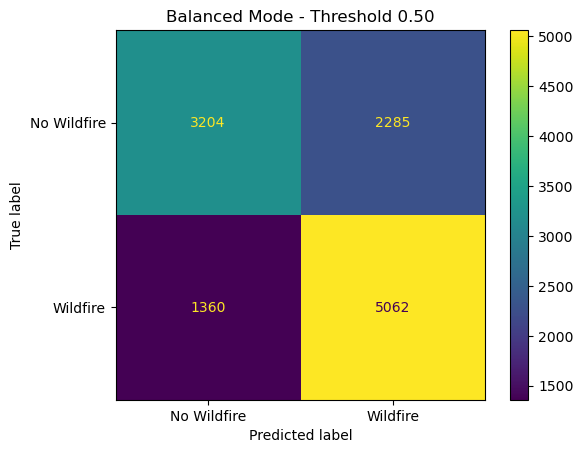

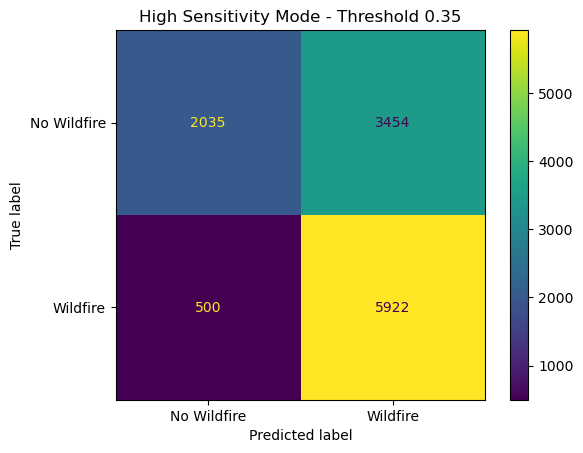

In [250]:
# Create confusion matrices
cm_low = confusion_matrix(
    y_test,
    y_test_pred_low_sensitivity
)

cm_high = confusion_matrix(
    y_test,
    y_test_pred_high_sensitivity
)

# Plot low-sensitivity configuration
fig, ax = plt.subplots()

ConfusionMatrixDisplay(
    confusion_matrix=cm_low,
    display_labels=["No Wildfire", "Wildfire"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Balanced Mode - Threshold 0.50")
plt.show()


# Plot high-sensitivity configuration
fig, ax = plt.subplots()

ConfusionMatrixDisplay(
    confusion_matrix=cm_high,
    display_labels=["No Wildfire", "Wildfire"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("High Sensitivity Mode - Threshold 0.35")
plt.show()

#### Interpretation

Lowering the threshold from 0.50 to 0.35 substantially increases the number of wildfire events detected by the model.

The high-sensitivity configuration reduces missed wildfires from 1,360 to 500, increasing wildfire recall from 78.8% to 92.2%. However, this comes at the cost of more false alarms, which increase from 2,285 to 3,454.

This demonstrates the trade-off between wildfire detection and false alarms when adjusting the classification threshold.

In [248]:
# Evaluate both sensitivity configurations on the test set.
sensitivity_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Wildfire Precision",
        "Wildfire Recall",
        "Wildfire F1",
        "No-Wildfire Recall"
    ],
    "Low Sensitivity (0.50)": [
        accuracy_score(y_test, y_test_pred_low_sensitivity),
        precision_score(y_test, y_test_pred_low_sensitivity),
        recall_score(y_test, y_test_pred_low_sensitivity),
        f1_score(y_test, y_test_pred_low_sensitivity),
        recall_score(y_test, y_test_pred_low_sensitivity, pos_label=0)
    ],
    "High Sensitivity (0.35)": [
        accuracy_score(y_test, y_test_pred_high_sensitivity),
        precision_score(y_test, y_test_pred_high_sensitivity),
        recall_score(y_test, y_test_pred_high_sensitivity),
        f1_score(y_test, y_test_pred_high_sensitivity),
        recall_score(y_test, y_test_pred_high_sensitivity, pos_label=0)
    ]
})

sensitivity_results

,Metric,Low Sensitivity (0.50),High Sensitivity (0.35)
0,Test Accuracy,0.693980,0.668038
1,Wildfire Precision,0.688989,0.631613
2,Wildfire Recall,0.788228,0.922143
3,Wildfire F1,0.735275,0.749715
4,No-Wildfire Recall,0.583713,0.370741


## Final Step — Feature Importance of the Reduced XGBoost Model

Objective: quantify the contribution of each of the 14 selected features to the predictions of the final reduced XGBoost model.

Method: SHAP (SHapley Additive exPlanations), calculated on the untouched test set.

Output: a global ranking of the 14 features based on their mean absolute SHAP value, showing which features have the greatest impact on the model's predictions.

This provides the final feature-level interpretation of the 14-feature XGBoost model.

#### Disclaimer:

Note on feature names: During the feature-engineering pipeline, some temporal features were labelled Average even though their underlying aggregation was median.

Precipitation is the exception: it uses the mean aggregation and therefore correctly retains the Average label.

This is a naming/labeling issue only. The underlying feature values, model training, hyperparameters, and evaluation results are unchanged. The corrected names are used when presenting the final feature importance results.

First, we will use permutation importance as a complementary analysis to assess how much each variable contributes to the model's predictive performance.

The results will provide an initial ranking of the features before using SHAP for a more detailed interpretation of the final model.

In [257]:
# Calculate permutation importance for the final 14-feature XGBoost model
perm_importance_14 = permutation_importance(
    xgb_reduced_final,
    X_test_reduced,
    y_test,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

# Create feature importance table
feature_importance_14 = pd.DataFrame({
    "Feature": X_test_reduced.columns,
    "Importance": perm_importance_14.importances_mean,
    "Std": perm_importance_14.importances_std
}).sort_values("Importance", ascending=False)

# Correct the displayed names only
feature_importance_14["Feature"] = (
    feature_importance_14["Feature"]
    .str.replace("_Average_", "_Median_", regex=False)
)

# Precipitation uses mean, so keep "Average"
feature_importance_14["Feature"] = (
    feature_importance_14["Feature"]
    .str.replace(
        "Precipitation_Median_",
        "Precipitation_Average_",
        regex=False
    )
)

# Convert importance to percentage points for easier interpretation
feature_importance_14["Importance_%"] = (
    feature_importance_14["Importance"] * 100
)

# Display a clean ranked table
feature_importance_14[
    ["Feature", "Importance_%", "Std"]
].style.format({
    "Importance_%": "{:.3f}%",
    "Std": "{:.4f}"
})

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,Feature,Importance_%,Std
0,Precipitation_Average_30_Days,7.838%,0.0039
9,Potential_Evapotranspiration_Median_30_Days,4.424%,0.0019
4,Solar_Radiation_Median_7_Days,3.085%,0.0020
6,Max_Daily_Temperature_Max_30_Days,2.838%,0.0018
2,Min_Relative_Humidity_Min_30_Days,2.698%,0.0026
5,Min_Daily_Temperature_Min_14_Days,2.187%,0.0014
1,Specific_Humidity_Median_30_Days,1.927%,0.0023
8,Vapor_Pressure_Deficit_Median_30_Days,1.787%,0.0015
10,Solar_Radiation_Today,1.540%,0.0020
11,Min_Relative_Humidity_Today,1.476%,0.0012


The permutation analysis shows that 30-day precipitation has the strongest measured contribution to model performance.
Other relevant features include potential evapotranspiration, solar radiation, temperature, and humidity.
This provides an initial feature ranking before using SHAP for a more detailed interpretation of the model.

In [265]:
# Calculate SHAP values for the final 14-feature XGBoost model
explainer = shap.TreeExplainer(xgb_reduced_final)
shap_values = explainer.shap_values(X_test_reduced)

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Convert to relative importance (%)
feature_importance_shap = pd.DataFrame({
    "Feature": X_test_reduced.columns,
    "Importance_%": (
        mean_abs_shap / mean_abs_shap.sum() * 100
    )
}).sort_values("Importance_%", ascending=False)

# Correct displayed names only
feature_importance_shap["Feature"] = (
    feature_importance_shap["Feature"]
    .str.replace("_Average_", "_Median_", regex=False)
)

# Precipitation uses mean, so keep "Average"
feature_importance_shap["Feature"] = (
    feature_importance_shap["Feature"]
    .str.replace(
        "Precipitation_Median_",
        "Precipitation_Average_",
        regex=False
    )
)

# Display as a clean ranked table
feature_importance_shap.style.format({
    "Importance_%": "{:.2f}%"
})

,Feature,Importance_%
0,Precipitation_Average_30_Days,17.25%
9,Potential_Evapotranspiration_Median_30_Days,11.96%
6,Max_Daily_Temperature_Max_30_Days,8.89%
11,Min_Relative_Humidity_Today,7.42%
2,Min_Relative_Humidity_Min_30_Days,6.98%
4,Solar_Radiation_Median_7_Days,6.39%
5,Min_Daily_Temperature_Min_14_Days,6.18%
12,Vapor_Pressure_Deficit_Today,6.03%
8,Vapor_Pressure_Deficit_Median_30_Days,5.77%
3,Max_Relative_Humidity_Max_7_Days,5.75%


In [267]:
# Save the final 14-feature XGBoost model
joblib.dump(
    xgb_reduced_final,
    "xgb_reduced_final.pkl"
)

# Save the exact feature order required by the model
feature_metadata = {
    "features": list(X_train_reduced.columns),
    "balanced_threshold": 0.50,
    "high_sensitivity_threshold": 0.35
}

with open("feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

print("Model and feature metadata exported successfully.")
print("\nFeatures:")
for i, feature in enumerate(feature_metadata["features"], 1):
    print(f"{i}. {feature}")

Model and feature metadata exported successfully.

Features:
1. Precipitation_Average_30_Days
2. Specific_Humidity_Average_30_Days
3. Min_Relative_Humidity_Min_30_Days
4. Max_Relative_Humidity_Max_7_Days
5. Solar_Radiation_Average_7_Days
6. Min_Daily_Temperature_Min_14_Days
7. Max_Daily_Temperature_Max_30_Days
8. Wind_Speed_Average_30_Days
9. Vapor_Pressure_Deficit_Average_30_Days
10. Potential_Evapotranspiration_Average_30_Days
11. Solar_Radiation_Today
12. Min_Relative_Humidity_Today
13. Vapor_Pressure_Deficit_Today
14. Wind_Speed_Today
